In [32]:
# Get and load color map (handles if it is in another folder)
from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd()
while not (cwd / "color_map.py").exists():
    cwd = cwd.parent
sys.path.insert(0, str(cwd))
from color_map import make_color_map

v_rest = [-22, -17, -12.3, -8.5]
pqif_vector = [0, 0.25, 0.5, 0.75, 1]
color_map_vrest = make_color_map(v_rest, plt.cm.Reds)  # Reds for vrest
color_map_pqif = make_color_map(pqif_vector[1:-1], plt.cm.Greens)  # Greens for pqif
color_map_pqif[pqif_vector[0]] = 'black'
color_map_pqif[pqif_vector[-1]] = 'steelblue'

# Load matplotlib style (handles if in another folder)
from pathlib import Path
cwd = Path.cwd()
while not (cwd / "plos.mplstyle").exists():
    cwd = cwd.parent

style_path = Path(cwd / 'plos.mplstyle')
plt.style.use(style_path)


from config import SimParam, Config  # Classes
from pathlib import Path

all_pqif = [0, 0.25, 0.5, 0.75, 1]
seeds = range(50)

# Oscillations
oscillation_sims = [
    SimParam(1, -8.5, 14.56),
    SimParam(2, -12.3, 10.76),
    SimParam(3, -17.0, 8.21),
    SimParam(4, -22.0, 7.33),
]

oscillations = Config(
    name="oscillations",
    sims=oscillation_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(oscillations))

# Sequences
sequence_sims = [
    SimParam(9, -8.5, 14.56),
    SimParam(10, -12.3, 10.76),
    SimParam(11, -17.0, 8.21),
    SimParam(12, -22.0, 7.33),
]

sequences = Config(
    name="sequences",
    sims=sequence_sims,
    pqif_numbers=all_pqif,
    seed_numbers=seeds
)

print(repr(sequences))

configs = [oscillations, sequences]


# Fig
figure_folder = Path("figures_all\july\motifs")
figure_folder.mkdir(parents=True, exist_ok=True)

# Base
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)


Config name: oscillations
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 1 : (vrest=-8.5, gain=14.56), 2 : (vrest=-12.3, gain=10.76), 3 : (vrest=-17.0, gain=8.21), 4 : (vrest=-22.0, gain=7.33)
  across 50 seeds
  Optional parameters:
[]
Config name: sequences
  pqif: [0, 0.25, 0.5, 0.75, 1]
  simulations: 9 : (vrest=-8.5, gain=14.56), 10 : (vrest=-12.3, gain=10.76), 11 : (vrest=-17.0, gain=8.21), 12 : (vrest=-22.0, gain=7.33)
  across 50 seeds
  Optional parameters:
[]


In [33]:
base_path = Path(r"J:\ordinary_simulations")  # Path to simulation files 
base_path.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd


weights_dict = {}
rows = []

for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    for sim_param, pqif, seed, _ in cfg.iter_params():
        sim = sim_param.sim
        vrest = sim_param.vrest
        gain = sim_param.gain

        
        simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'  # Shared across dataframe and dictionary

        # ------------------------------ Initial matrix (with zero weights) ------------------------------
        file_path_iloop_0 = base_path / f"simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_0_seed_{seed}"

        M = np.loadtxt(file_path_iloop_0, delimiter=',')

        # ------------------------------ Info about sparsity ------------------------------

        zeros = M == 0  # matrix indicating which weights were initialized to zero
        num_zero_weights = np.sum(zeros)
        num_non_zero_weights = np.sum(~zeros)
        frac_zero_weights = f"{np.sum(zeros) / M.size:.2f}" # should be around 0.7

        # ------------------------------ Matrix after training ------------------------------

        # Load matrix
        file_path_iloop_11 = base_path / f'simulation_{sim}\simulation_{sim}_connectivity_matrix\simulation_{sim}_connectivity_pqif_{pqif}_iloop_11_seed_{seed}'

        W_unfiltered = np.loadtxt(file_path_iloop_11, delimiter=',')

        # ------------------------------ Filtered data: Exclude weights initialized to zero ------------------------------
        
        W_filtered = W_unfiltered[~zeros]  # Omit zeros, becomes 1D
        weights_dict[simulation_id] = W_filtered  # Add filtered weights to dictionary; is flattened

        mean = np.mean(W_filtered)  # Mean
        std_pop = np.std(W_filtered)  # Standard deviation (population)
        std_sample = np.std(W_filtered, ddof=1)  # Standard deviation (sample)

        if pqif == 1:
            gain = 10.74


        # ------------------------------ Final stats ------------------------------


        row = [simulation_id, cfg.name, sim, vrest, gain, 
                pqif, seed, mean, std_pop, std_sample, 
                num_zero_weights, num_non_zero_weights, frac_zero_weights]  # Store all data associated with the connectivity matrix + a simulationID to the weights in dictionary
        rows.append(row)  # Append row to what becomes the dataframe later

# ------------------------------ Make dataframe ------------------------------

columns = ['config', 'dynamic', 'simulation', 'vrest', 'gain', 
           'pqif', 'seed',  'mean', 'std_pop', 'std_sample', 
           'num_zero_weights', 'num_non_zero_weights', 'frac_zero_weights']
df = pd.DataFrame(rows, columns=columns)
df.to_csv("statistics_connectivity.csv", index=False)

# Part to copy for reusing csv
loaded_df = pd.read_csv("statistics_connectivity.csv") 
wDF = loaded_df.copy()
wDF.head(5)

0: oscillations
1: sequences


,config,dynamic,simulation,vrest,gain,pqif,seed,mean,std_pop,std_sample,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_sim_1_pqif_0_seed_0,oscillations,1,-8.5,14.56,0.0,0,0.000267,0.426141,0.426159,28062,11938,0.7
1,oscillations_sim_1_pqif_0_seed_1,oscillations,1,-8.5,14.56,0.0,1,-0.000349,0.426364,0.426382,28063,11937,0.7
2,oscillations_sim_1_pqif_0_seed_2,oscillations,1,-8.5,14.56,0.0,2,0.000812,0.399953,0.399970,28070,11930,0.7
3,oscillations_sim_1_pqif_0_seed_3,oscillations,1,-8.5,14.56,0.0,3,0.000729,0.420193,0.420211,28062,11938,0.7
4,oscillations_sim_1_pqif_0_seed_4,oscillations,1,-8.5,14.56,0.0,4,0.000024,0.441818,0.441836,28068,11932,0.7


In [34]:
for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    dfs = []
    
    for sim_param in cfg.sims:

        sim = sim_param.sim
        gain = sim_param.gain
        vrest = sim_param.vrest
        seeds = cfg.seed_numbers

        for seed in seeds:

            simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'
            print(simulation_id)




        

0: oscillations
oscillations_sim_1_pqif_1_seed_0
oscillations_sim_1_pqif_1_seed_1
oscillations_sim_1_pqif_1_seed_2
oscillations_sim_1_pqif_1_seed_3
oscillations_sim_1_pqif_1_seed_4
oscillations_sim_1_pqif_1_seed_5
oscillations_sim_1_pqif_1_seed_6
oscillations_sim_1_pqif_1_seed_7
oscillations_sim_1_pqif_1_seed_8
oscillations_sim_1_pqif_1_seed_9
oscillations_sim_1_pqif_1_seed_10
oscillations_sim_1_pqif_1_seed_11
oscillations_sim_1_pqif_1_seed_12
oscillations_sim_1_pqif_1_seed_13
oscillations_sim_1_pqif_1_seed_14
oscillations_sim_1_pqif_1_seed_15
oscillations_sim_1_pqif_1_seed_16
oscillations_sim_1_pqif_1_seed_17
oscillations_sim_1_pqif_1_seed_18
oscillations_sim_1_pqif_1_seed_19
oscillations_sim_1_pqif_1_seed_20
oscillations_sim_1_pqif_1_seed_21
oscillations_sim_1_pqif_1_seed_22
oscillations_sim_1_pqif_1_seed_23
oscillations_sim_1_pqif_1_seed_24
oscillations_sim_1_pqif_1_seed_25
oscillations_sim_1_pqif_1_seed_26
oscillations_sim_1_pqif_1_seed_27
oscillations_sim_1_pqif_1_seed_28
oscillat

In [35]:
cfg.pqif_numbers

[0, 0.25, 0.5, 0.75, 1]

Used seed 47
0: oscillations


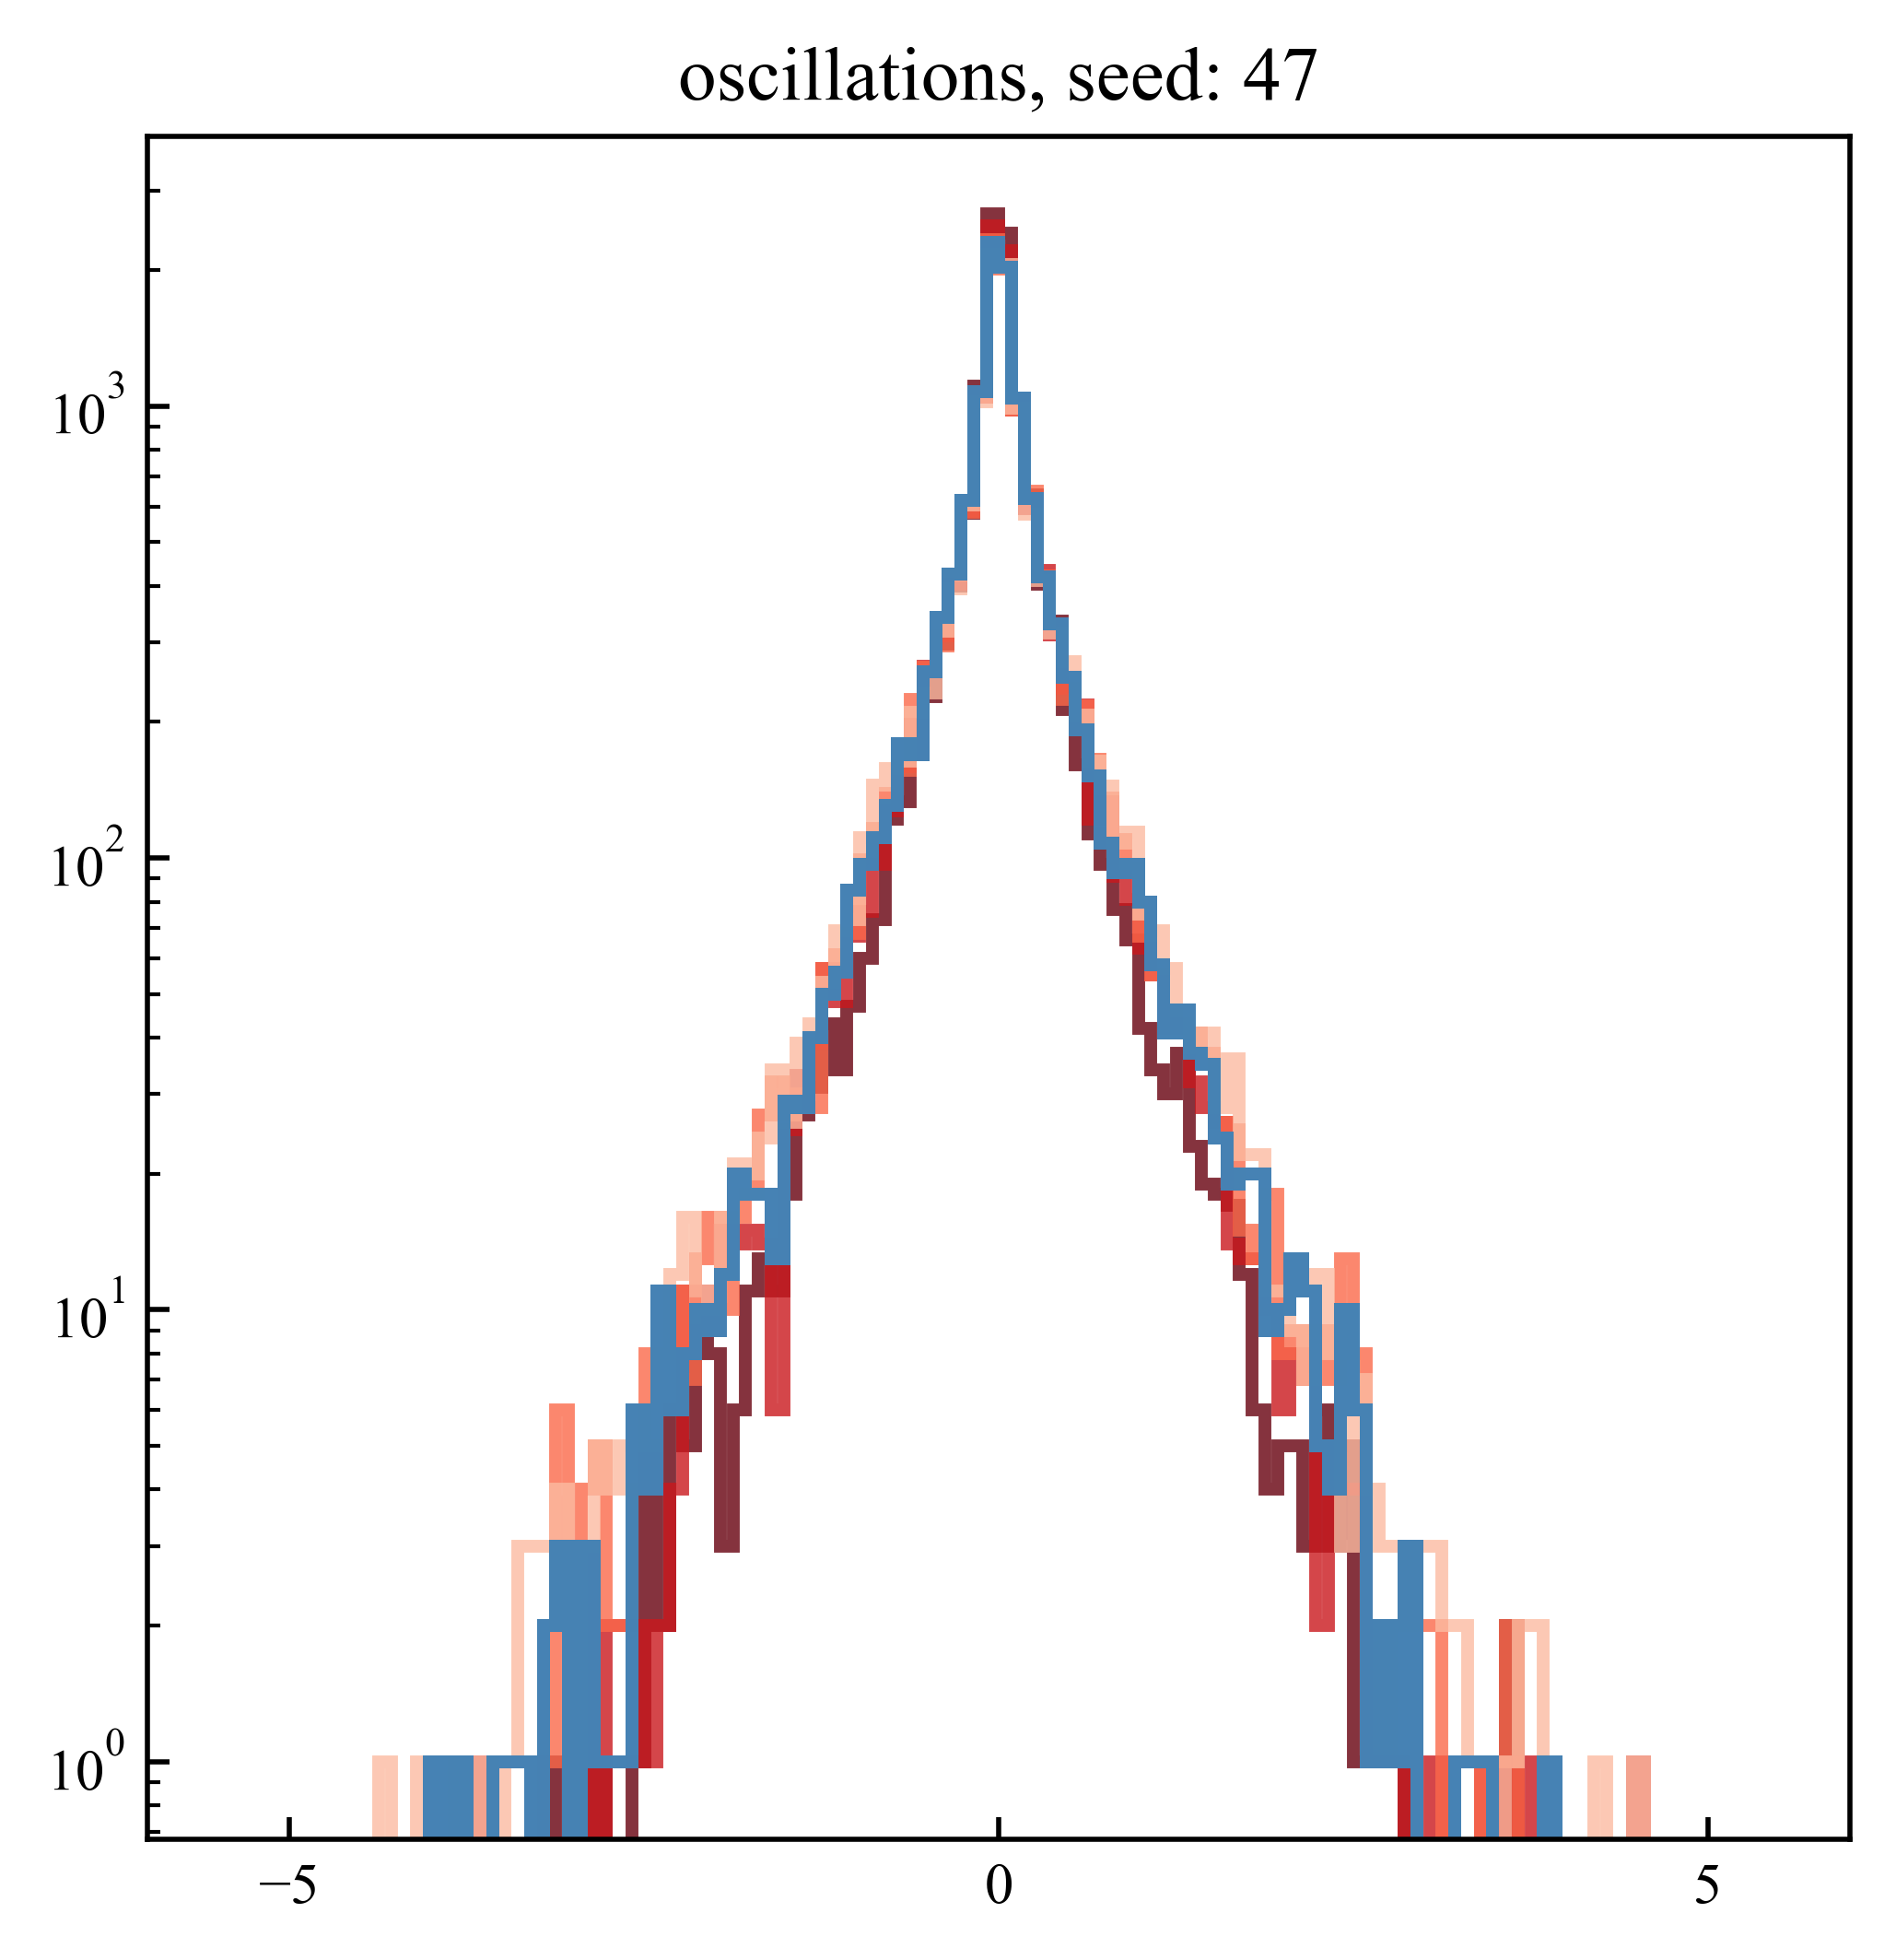

1: sequences


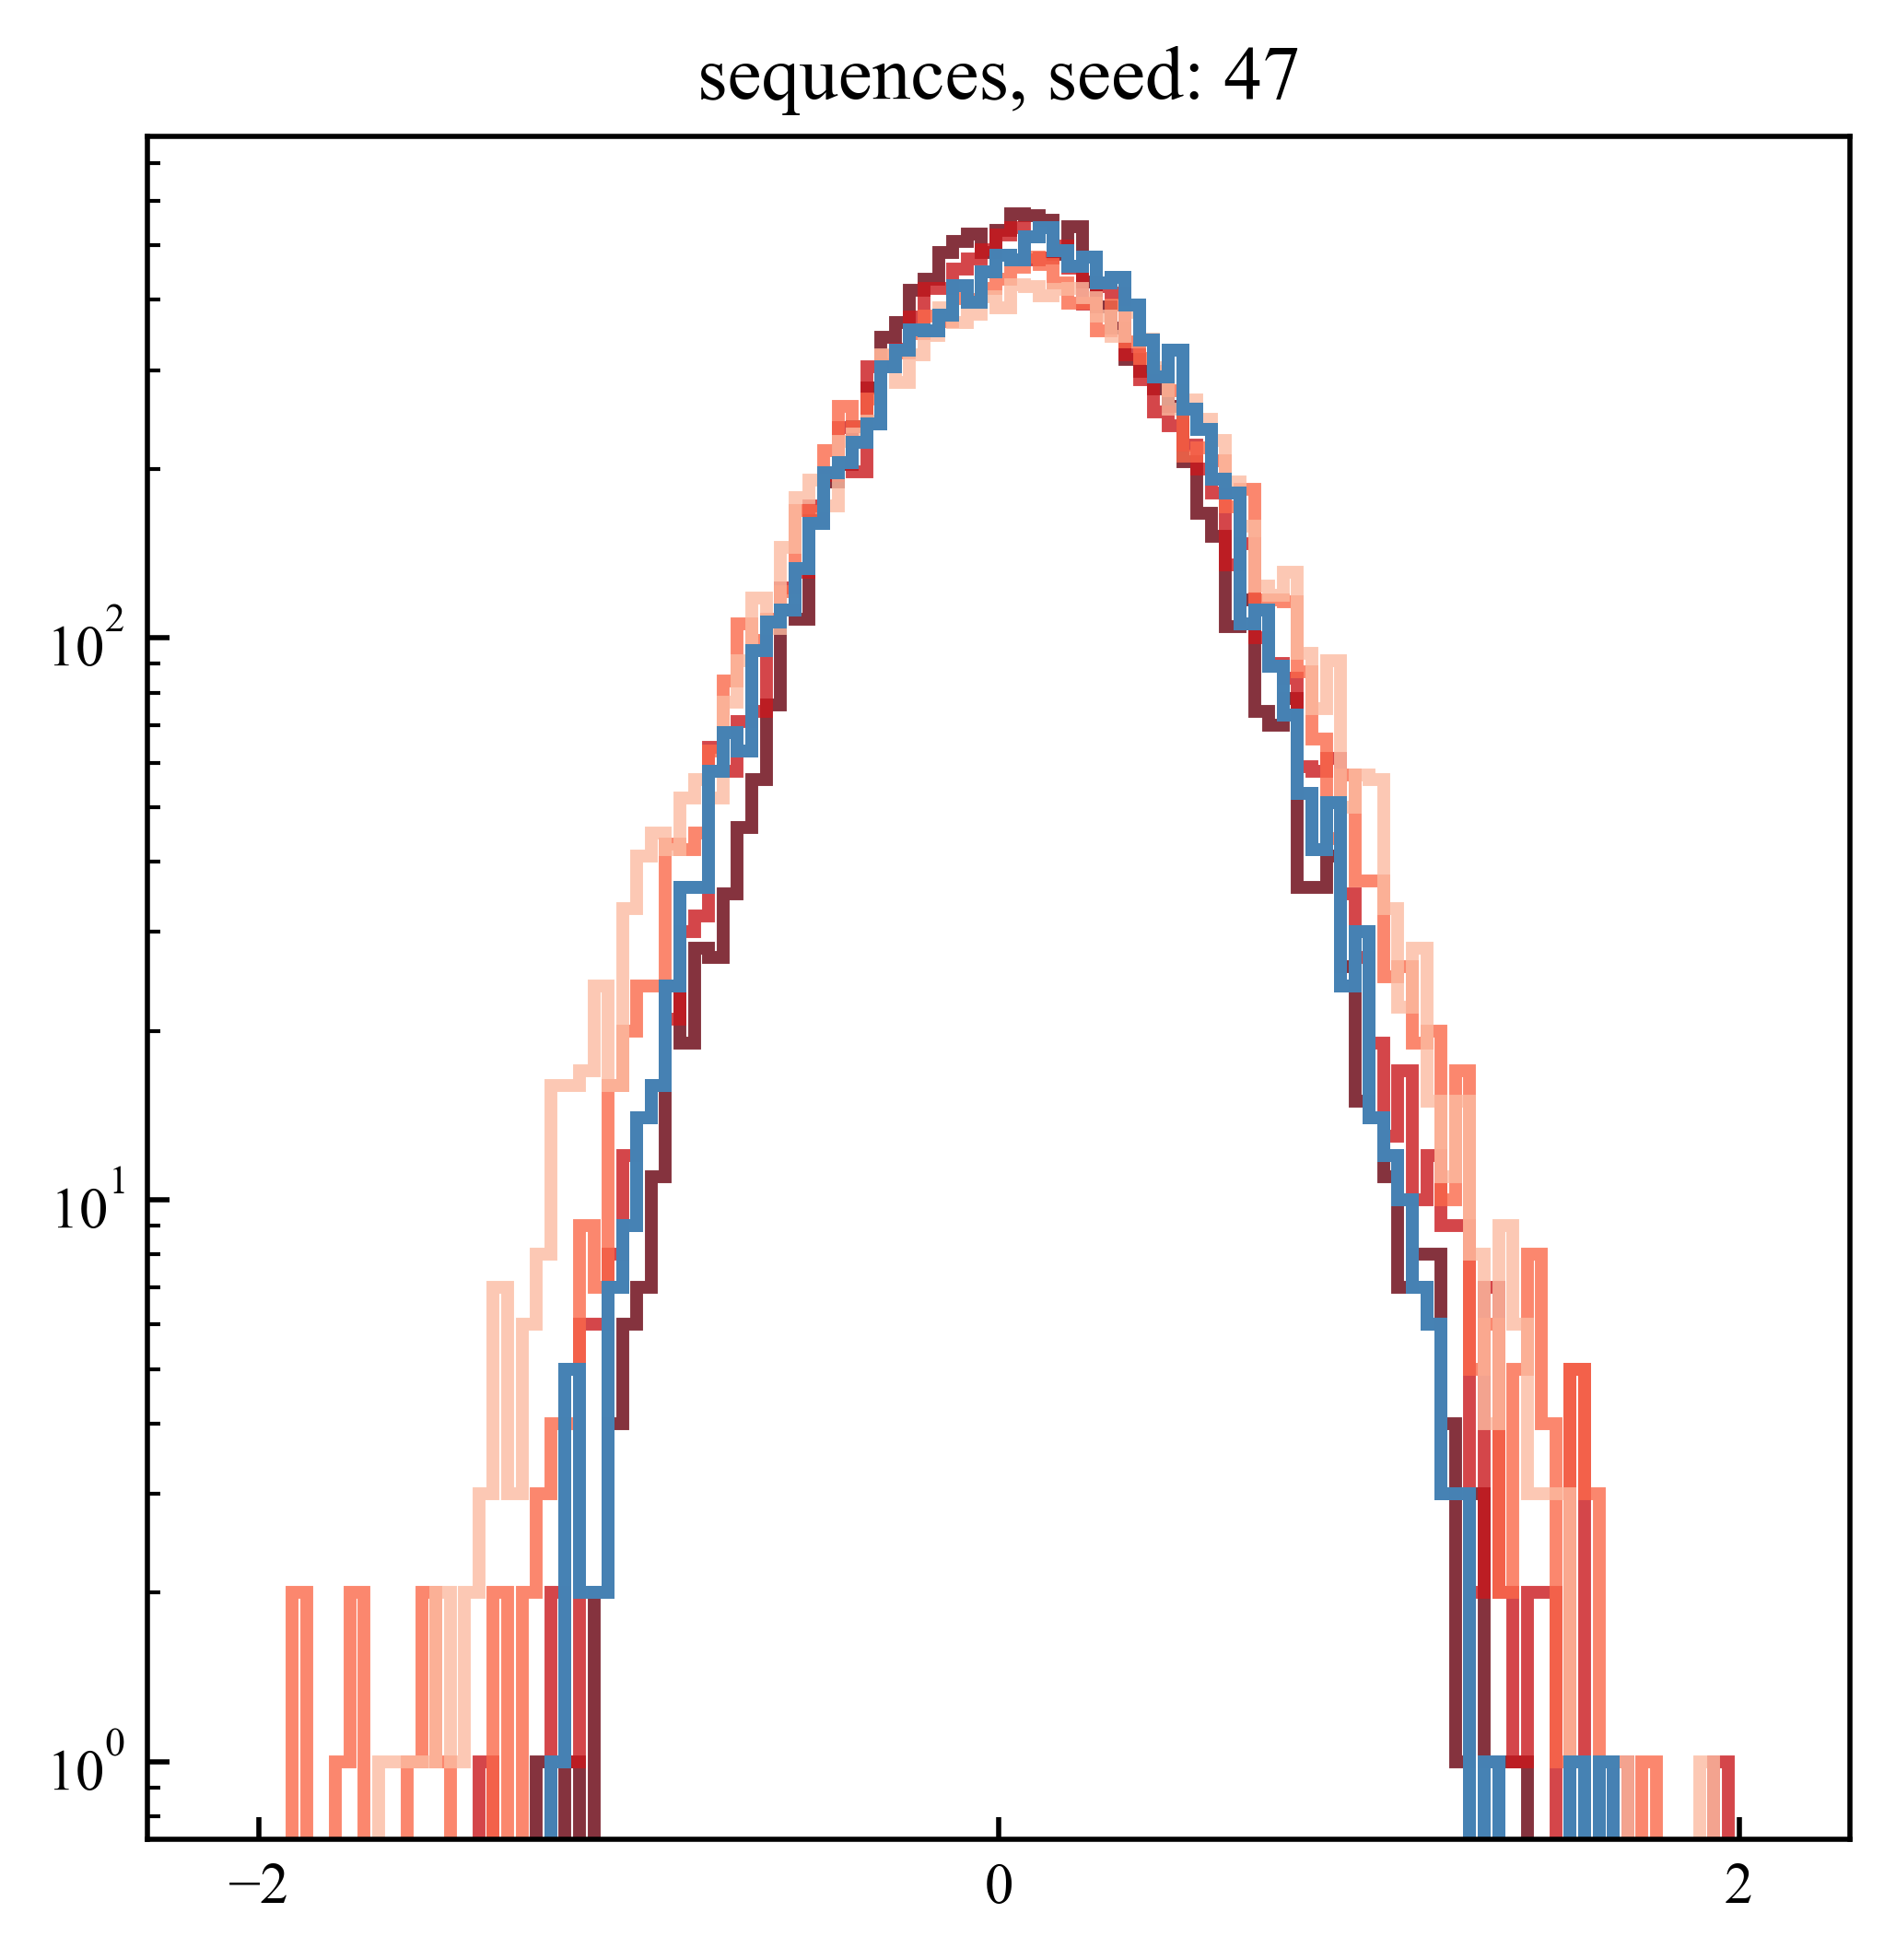

In [36]:
import random

seed = random.randint(1, 49) # randomize which seed we use
print(f"Used seed {seed}")
pqif_homogeneous = [0, 1]

for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    dfs = []


    all_weights = []

    for pqif in pqif_homogeneous:
    
        for sim_param in cfg.sims:

            sim = sim_param.sim
            gain = sim_param.gain
            vrest = sim_param.vrest


            simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'

            w = weights_dict[simulation_id]
            all_weights.append(w)

            # Shared bin range across all histograms in this figure
            xmin = min(np.min(w) for w in all_weights)
            xmax = max(np.max(w) for w in all_weights)

            bins = np.linspace(xmin, xmax, 101) # 31 edges gives 30 bins

    fig, ax = plt.subplots()
    for pqif in pqif_homogeneous:

        for sim_param in cfg.sims:

            sim = sim_param.sim
            gain = sim_param.gain
            vrest = sim_param.vrest

            simulation_id = f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'
            w = weights_dict[simulation_id]

            if pqif == 0:
                color=color_map_vrest[vrest]
            else:
                color="steelblue"

            ax.hist(w, bins=bins, histtype="step", linewidth=2, log=True, color=color, alpha=0.8)
            ax.set_xticks([-5, 0, 5] if cfg.name == "oscillations" else [-2, 0, 2])
            ax.set_xlim([-6, 6] if cfg.name == "oscillations" else [-2.3, 2.3])
            ax.set_title(f"{cfg.name}, seed: {seed}")
            ax.set_box_aspect(1)
    plt.show()






In [37]:
cfg.sim_numbers

[9, 10, 11, 12]

0: oscillations


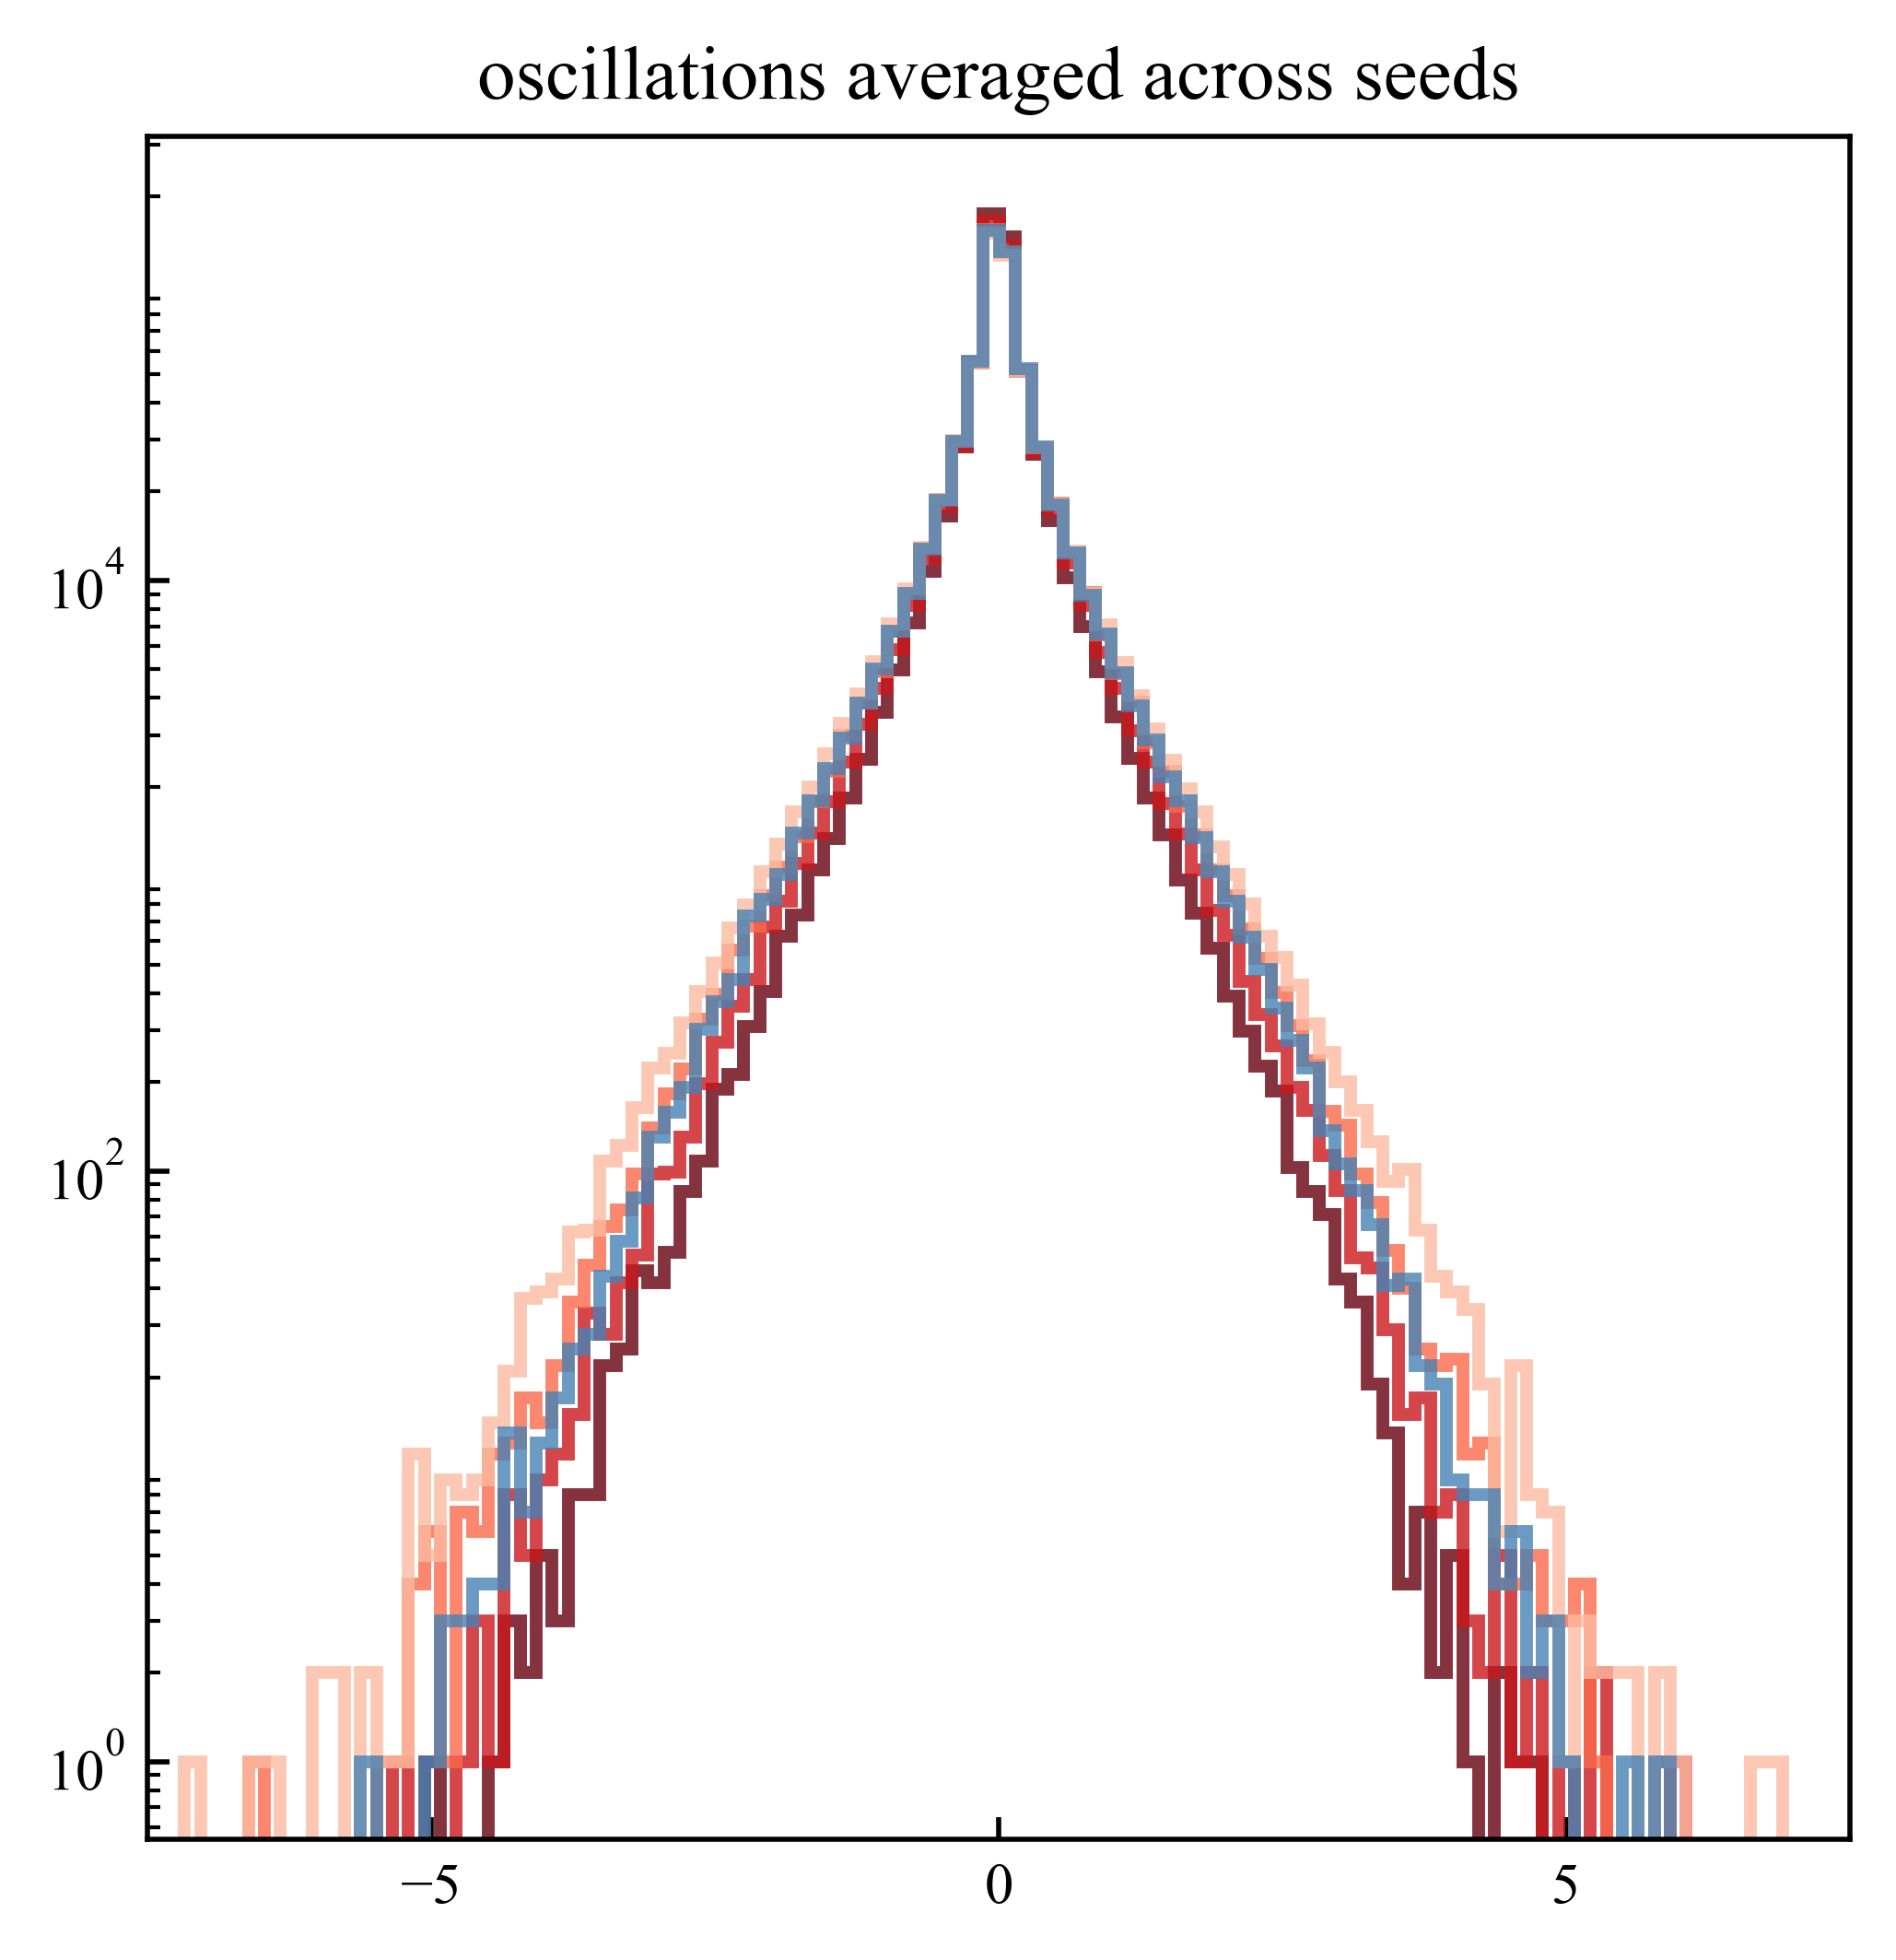

1: sequences


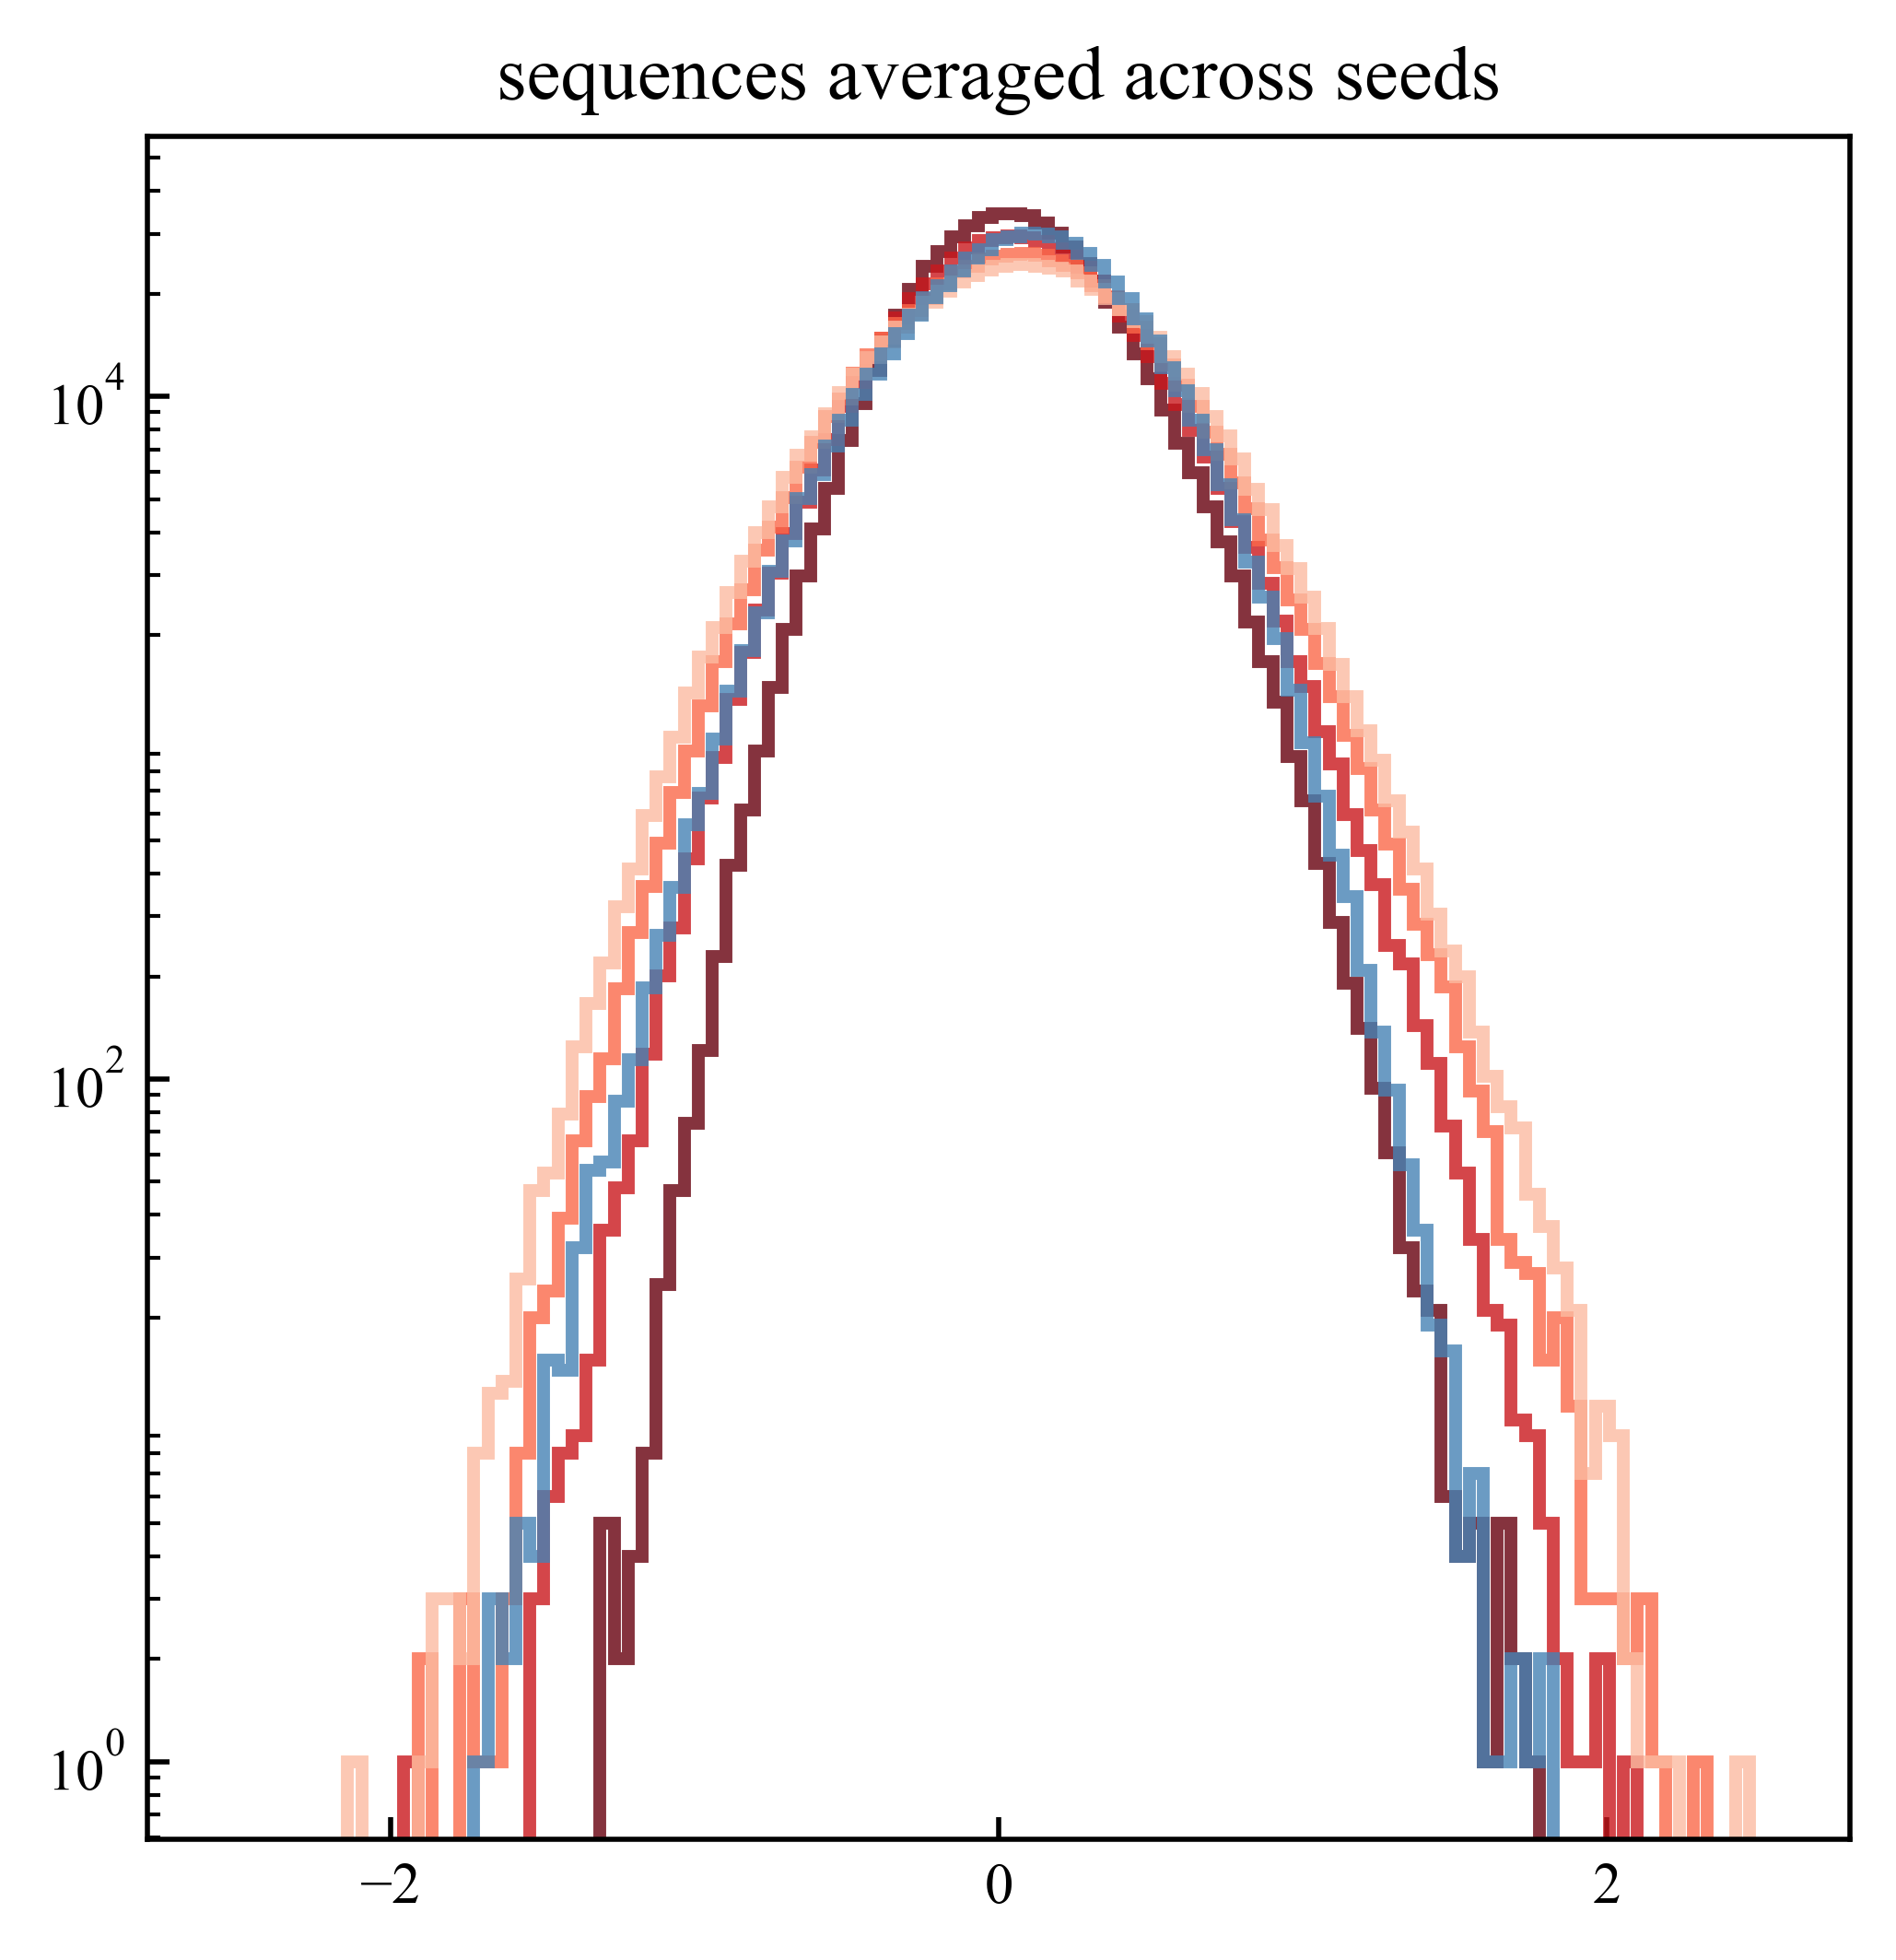

In [38]:
import numpy as np
import matplotlib.pyplot as plt

seeds = range(1, 50)
pqif_homogeneous = [0, 1]

for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    all_weights = []

    # Collect all weights to determine shared bins
    for pqif in pqif_homogeneous:

        for sim_param in cfg.sims:

            sim = sim_param.sim
            gain = sim_param.gain
            vrest = sim_param.vrest

            for seed in seeds:

                simulation_id = (
                    f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'
                )

                w = weights_dict[simulation_id]
                all_weights.append(w)

    xmin = min(np.min(w) for w in all_weights)
    xmax = max(np.max(w) for w in all_weights)

    bins = np.linspace(xmin, xmax, 101)

    fig, ax = plt.subplots()

    for pqif in pqif_homogeneous:

        for sim_param in cfg.sims:

            sim = sim_param.sim
            gain = sim_param.gain
            vrest = sim_param.vrest

            weights_across_seeds = []

            for seed in seeds:

                simulation_id = (
                    f'{cfg.name}_sim_{sim}_pqif_{pqif}_seed_{seed}'
                )

                w = weights_dict[simulation_id]
                weights_across_seeds.append(w)

            # Combine all weights from all seeds
            weights_across_seeds = np.concatenate(
                weights_across_seeds
            )

            if pqif == 0:
                color = color_map_vrest[vrest]
            else:
                color = "steelblue"

            if pqif == 1 and sim != cfg.sim_numbers[0]:
                continue  # only plot qif once

            ax.hist(
                weights_across_seeds,
                bins=bins,
                histtype="step",
                linewidth=2,
                log=True,
                color=color,
                alpha=0.8
            )

            ax.set_xticks([-5, 0, 5] if cfg.name == "oscillations" else [-2, 0, 2])
            ax.set_xlim([-7.5, 7.5] if cfg.name == "oscillations" else [-2.8, 2.8])
            yticks = [10**0, 10**2, 10**4] 
            ax.set_yticks(yticks)
            ax.set_box_aspect(1)
            ax.set_title(f"{cfg.name} averaged across seeds")


    fig_path = figure_folder / f"{cfg.name}_homogeneous_histogram.svg"
    plt.savefig(fig_path, format="svg", bbox_inches="tight")
    plt.show()

In [39]:
print(np.linspace(10**0, 10**4, 3))

print([10**0, 10**2, 10**4])

[1.0000e+00 5.0005e+03 1.0000e+04]
[1, 100, 10000]


In [40]:
df = pd.read_csv("statistics_connectivity.csv")

df

,config,dynamic,simulation,vrest,gain,pqif,seed,mean,std_pop,std_sample,num_zero_weights,num_non_zero_weights,frac_zero_weights
0,oscillations_sim_1_pqif_0_seed_0,oscillations,1,-8.5,14.56,0.0,0,0.000267,0.426141,0.426159,28062,11938,0.7
1,oscillations_sim_1_pqif_0_seed_1,oscillations,1,-8.5,14.56,0.0,1,-0.000349,0.426364,0.426382,28063,11937,0.7
2,oscillations_sim_1_pqif_0_seed_2,oscillations,1,-8.5,14.56,0.0,2,0.000812,0.399953,0.399970,28070,11930,0.7
3,oscillations_sim_1_pqif_0_seed_3,oscillations,1,-8.5,14.56,0.0,3,0.000729,0.420193,0.420211,28062,11938,0.7
4,oscillations_sim_1_pqif_0_seed_4,oscillations,1,-8.5,14.56,0.0,4,0.000024,0.441818,0.441836,28068,11932,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sequences_sim_12_pqif_1_seed_45,sequences,12,-22.0,10.74,1.0,45,0.073809,0.377824,0.377840,28059,11941,0.7
1996,sequences_sim_12_pqif_1_seed_46,sequences,12,-22.0,10.74,1.0,46,0.074611,0.346288,0.346303,28064,11936,0.7
1997,sequences_sim_12_pqif_1_seed_47,sequences,12,-22.0,10.74,1.0,47,0.072006,0.375534,0.375550,28053,11947,0.7
1998,sequences_sim_12_pqif_1_seed_48,sequences,12,-22.0,10.74,1.0,48,0.072128,0.374107,0.374123,28054,11946,0.7


In [41]:
df = pd.read_csv("statistics_connectivity.csv")

df_filtered = df[(df["pqif"])==1]

df_filtered

,config,dynamic,simulation,vrest,gain,pqif,seed,mean,std_pop,std_sample,num_zero_weights,num_non_zero_weights,frac_zero_weights
200,oscillations_sim_1_pqif_1_seed_0,oscillations,1,-8.5,10.74,1.0,0,-0.000483,0.534344,0.534366,28062,11938,0.7
201,oscillations_sim_1_pqif_1_seed_1,oscillations,1,-8.5,10.74,1.0,1,-0.000115,0.534623,0.534645,28063,11937,0.7
202,oscillations_sim_1_pqif_1_seed_2,oscillations,1,-8.5,10.74,1.0,2,0.002945,0.520702,0.520724,28070,11930,0.7
203,oscillations_sim_1_pqif_1_seed_3,oscillations,1,-8.5,10.74,1.0,3,0.001535,0.532159,0.532181,28062,11938,0.7
204,oscillations_sim_1_pqif_1_seed_4,oscillations,1,-8.5,10.74,1.0,4,-0.000984,0.545513,0.545535,28068,11932,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,sequences_sim_12_pqif_1_seed_45,sequences,12,-22.0,10.74,1.0,45,0.073809,0.377824,0.377840,28059,11941,0.7
1996,sequences_sim_12_pqif_1_seed_46,sequences,12,-22.0,10.74,1.0,46,0.074611,0.346288,0.346303,28064,11936,0.7
1997,sequences_sim_12_pqif_1_seed_47,sequences,12,-22.0,10.74,1.0,47,0.072006,0.375534,0.375550,28053,11947,0.7
1998,sequences_sim_12_pqif_1_seed_48,sequences,12,-22.0,10.74,1.0,48,0.072128,0.374107,0.374123,28054,11946,0.7


oscillations


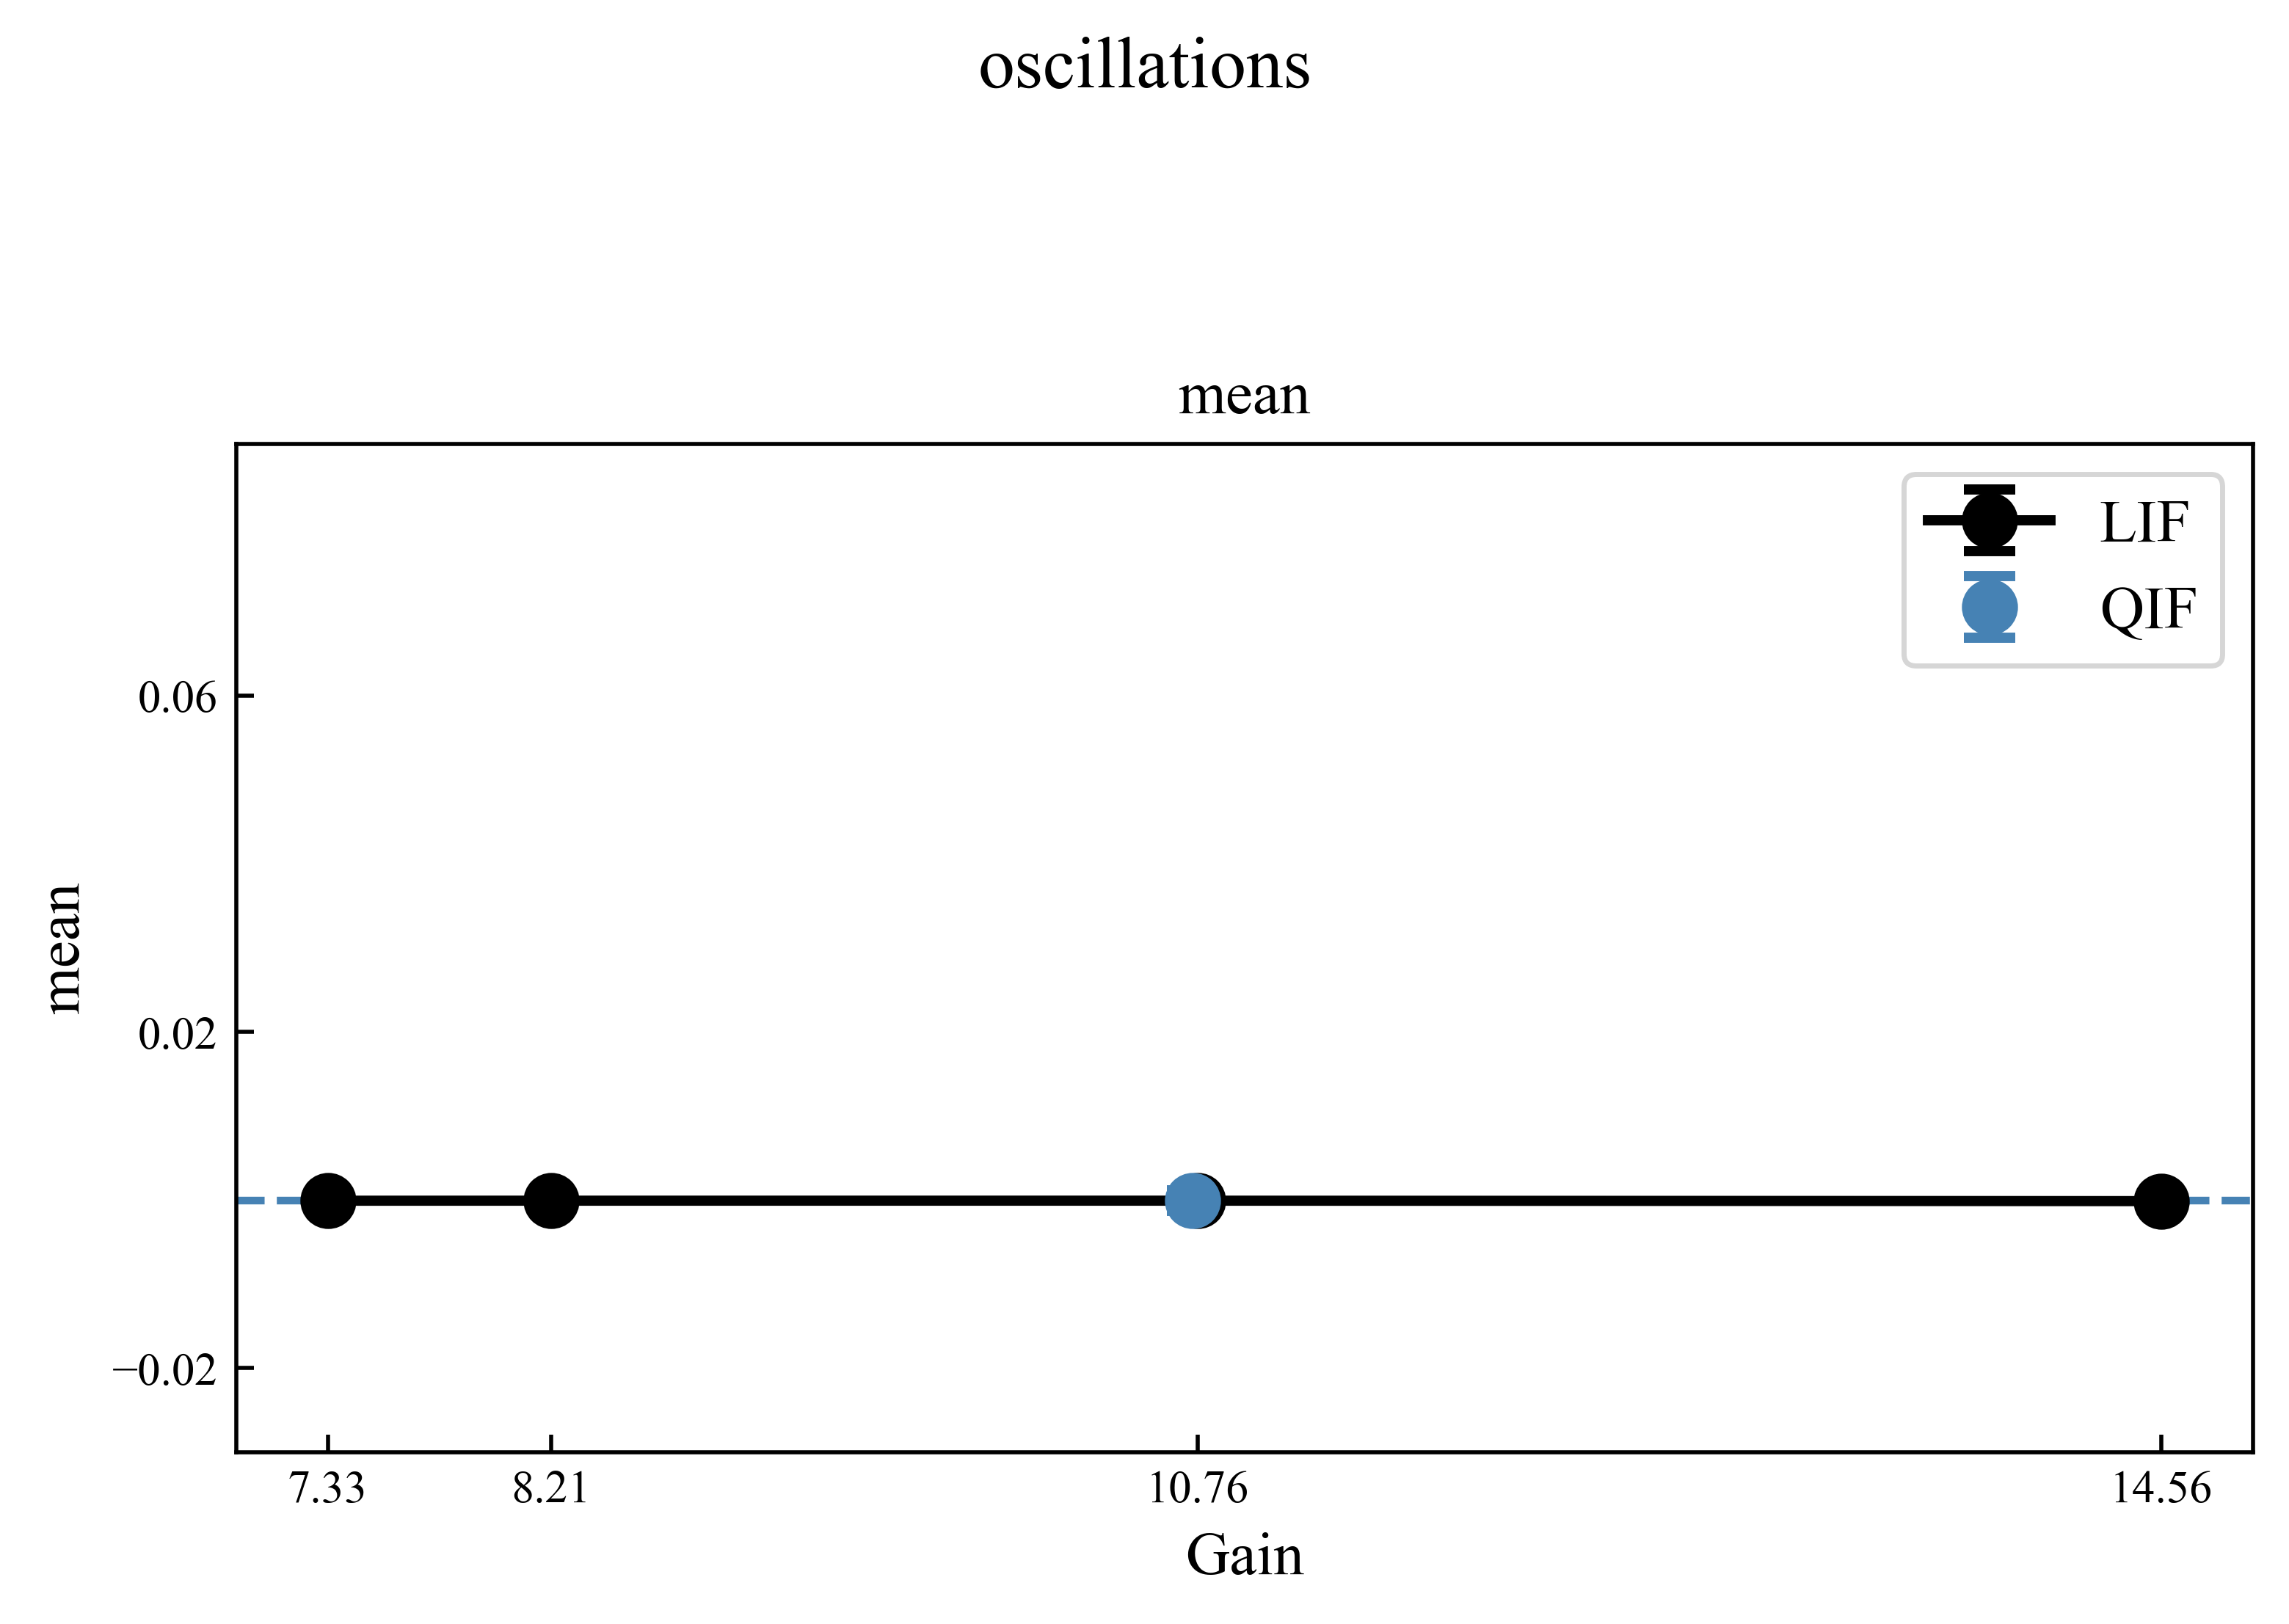

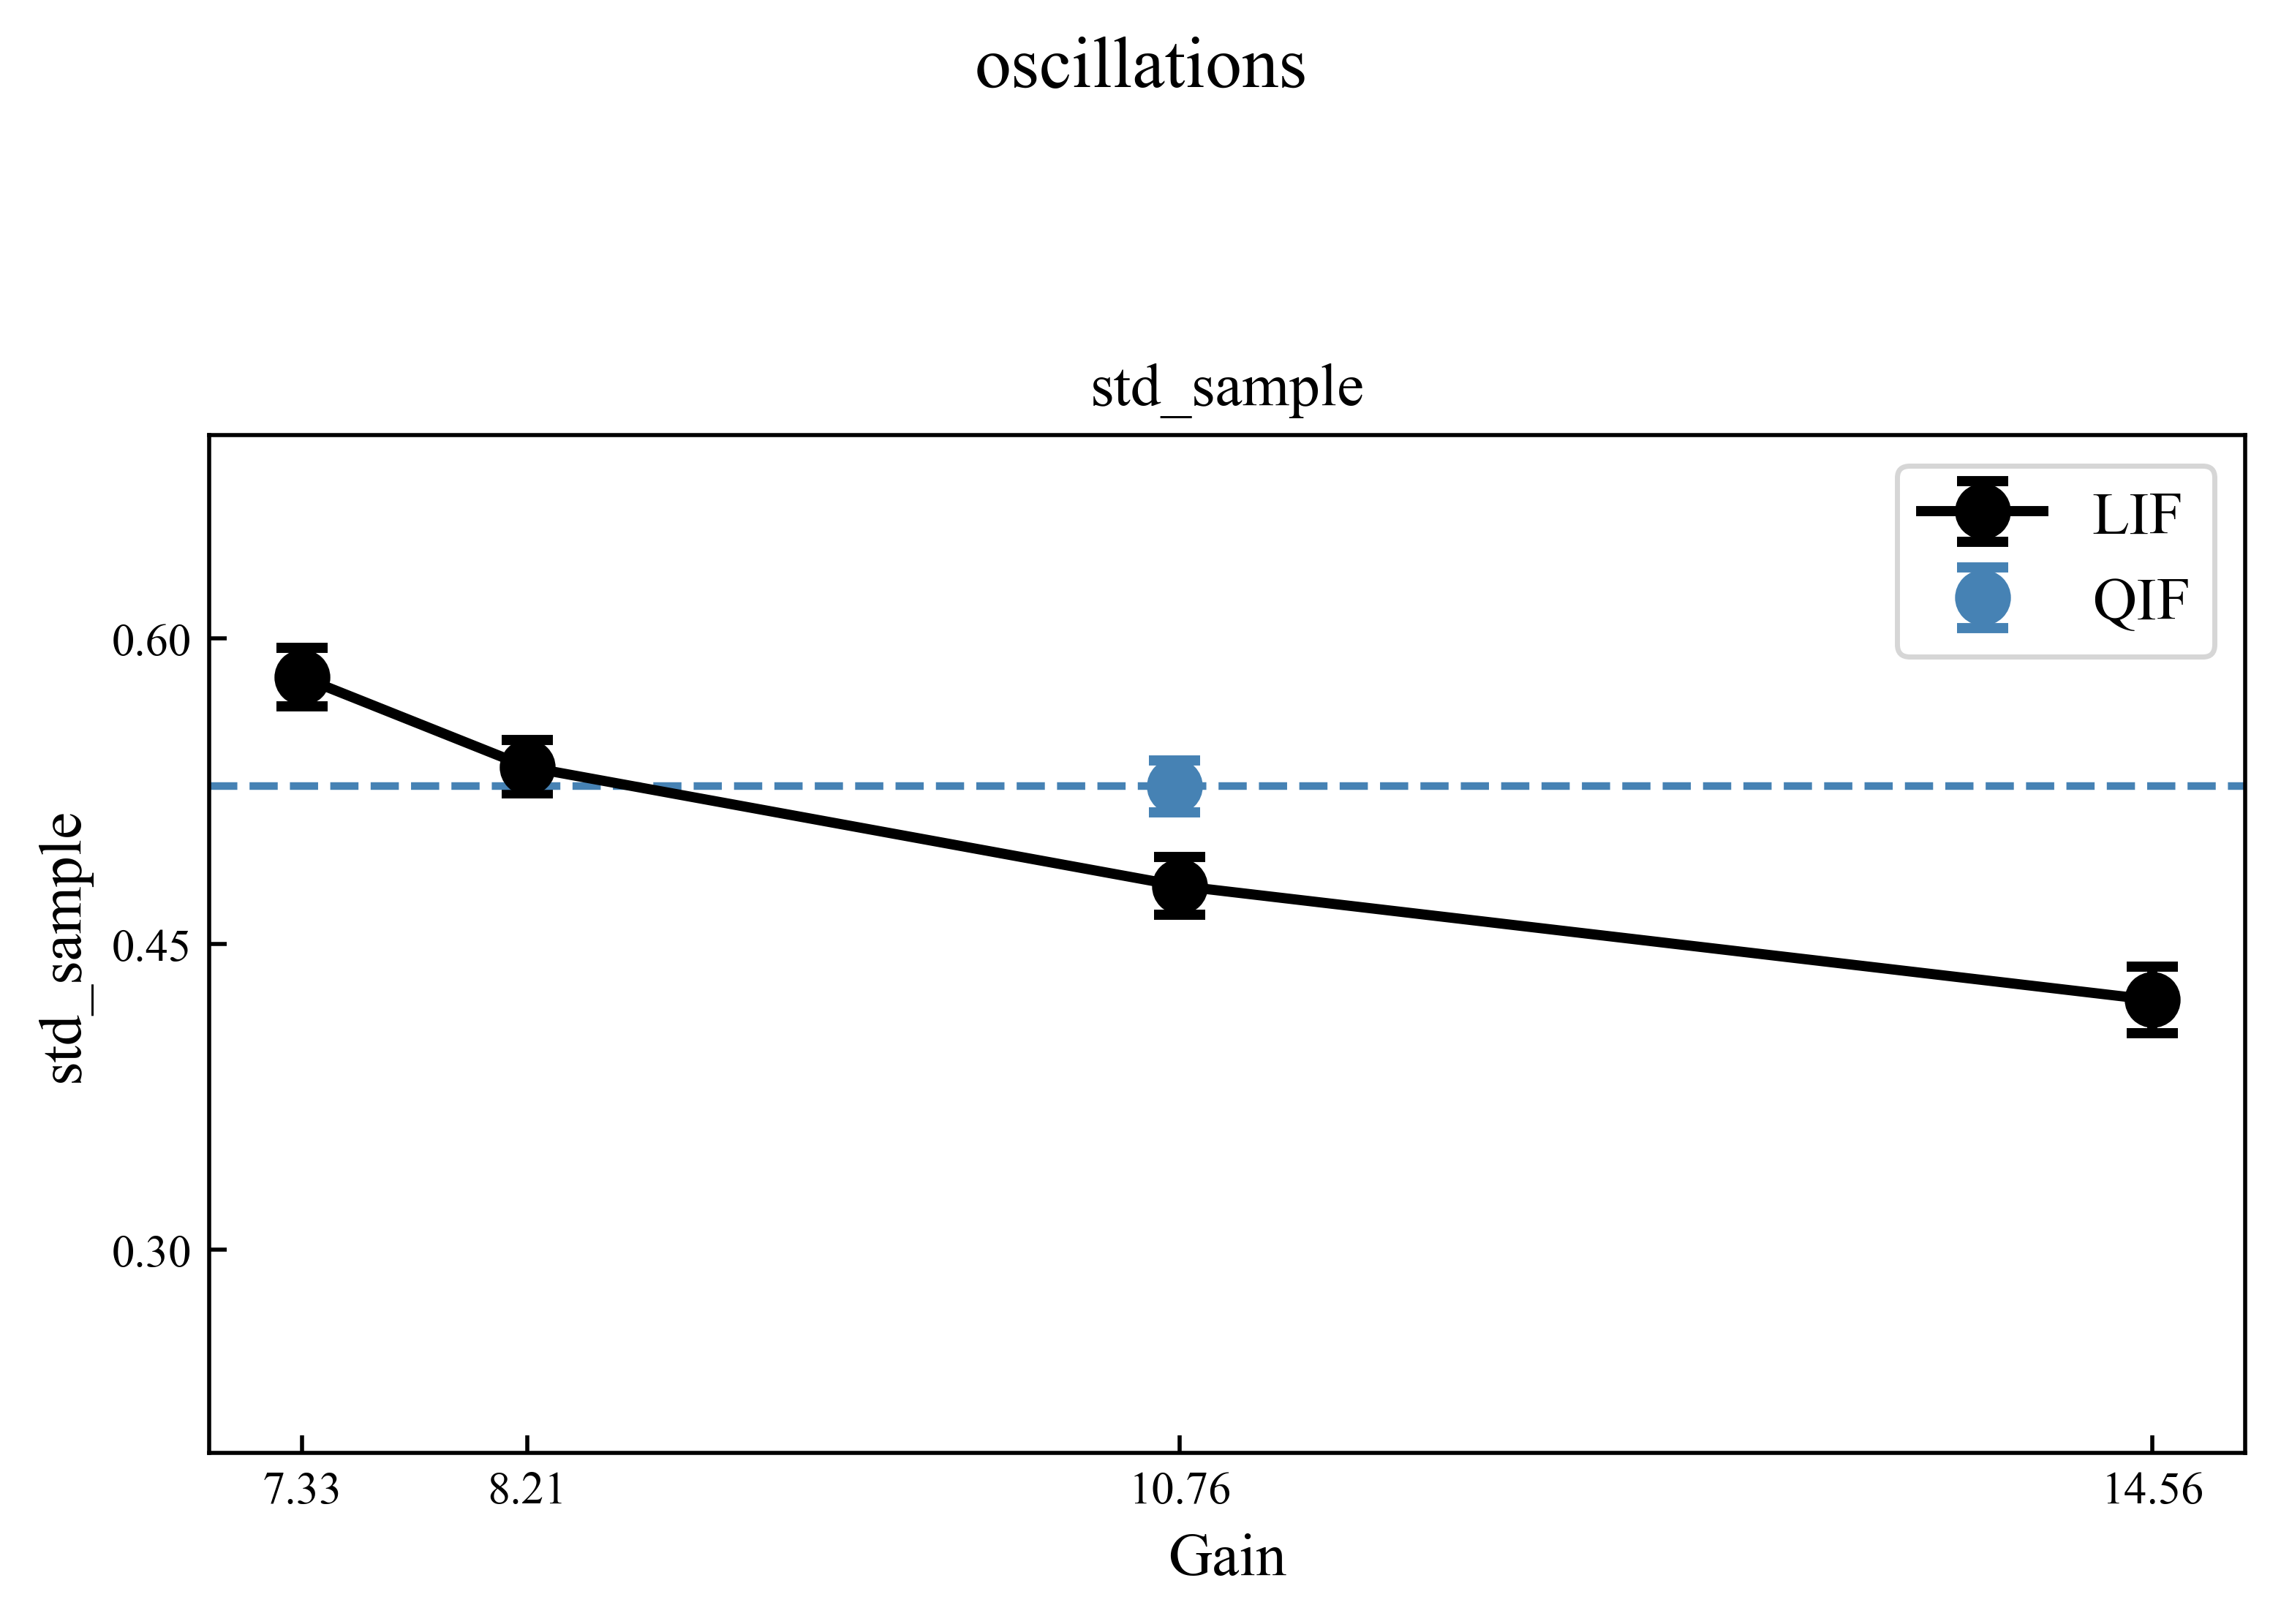

sequences


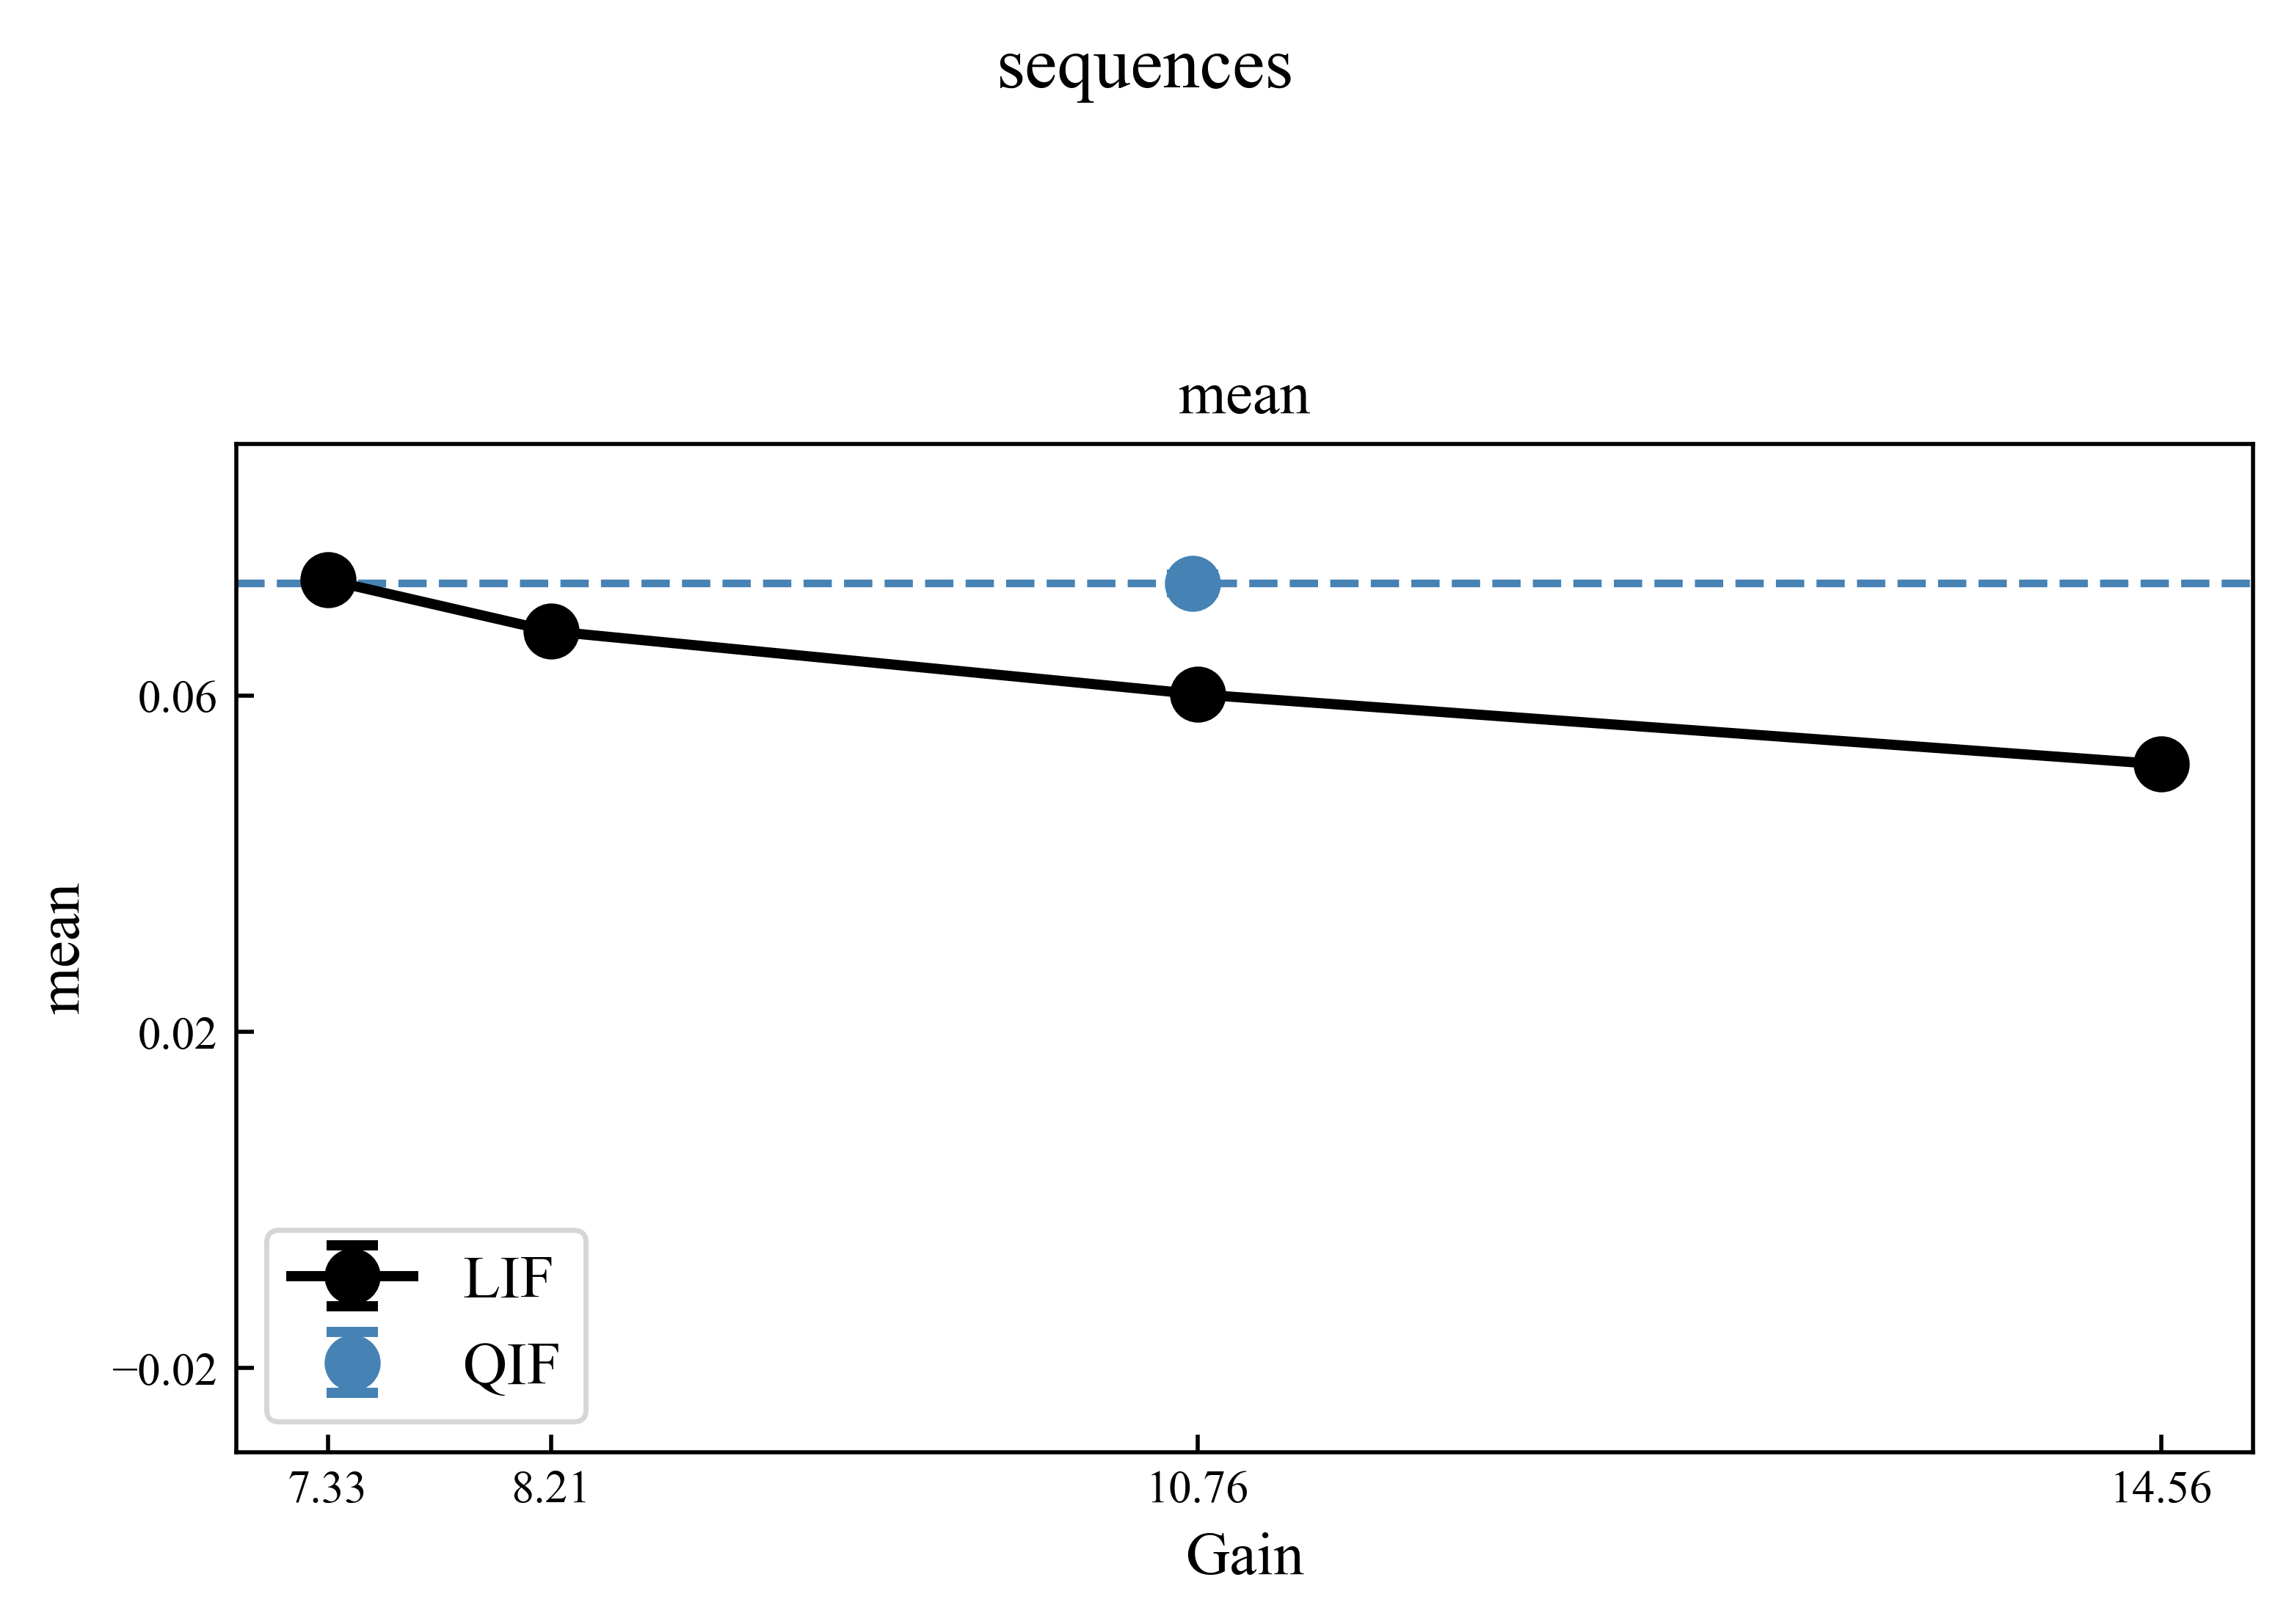

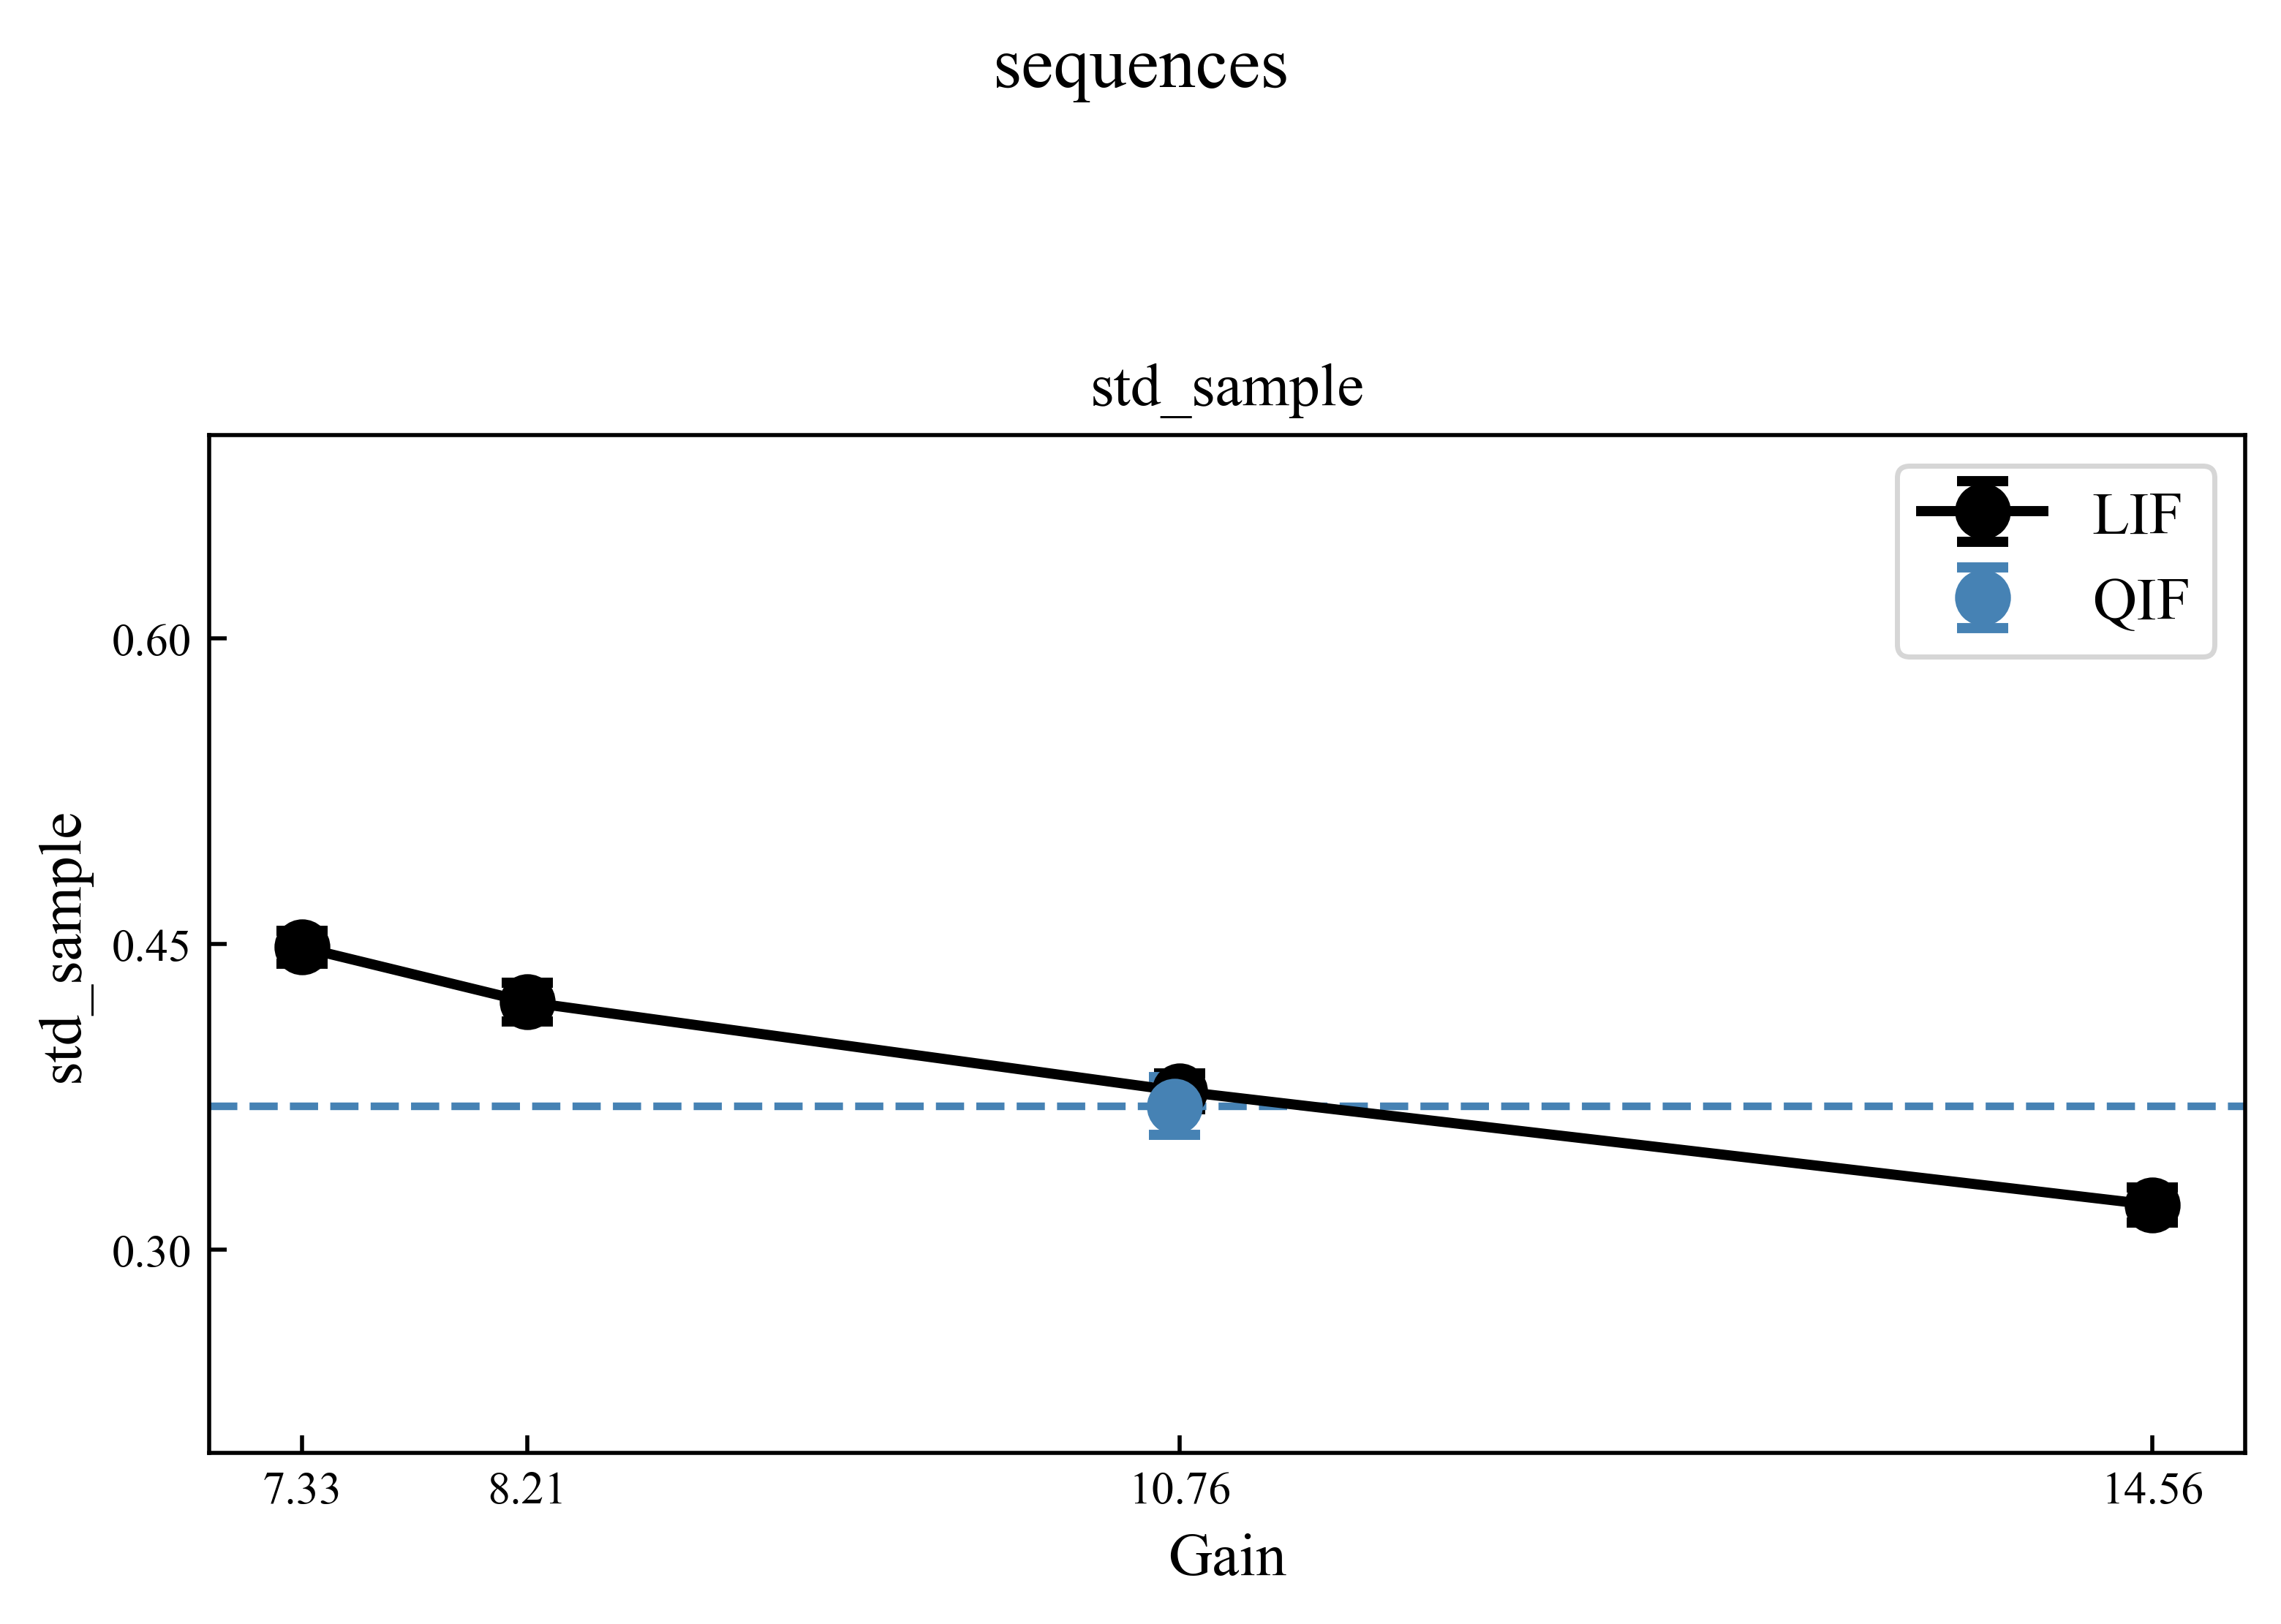

In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Parameters ----------------

base_path = Path(r"J:\ordinary_simulations")
figure_folder = Path(r"figures_all\july\motifs")
figure_folder.mkdir(parents=True, exist_ok=True)

pqif_homogeneous = [0, 1]
quantifications = ["mean", "std_sample"]

df = pd.read_csv("statistics_connectivity.csv")

for cfg in configs:
    print(cfg.name)

    df_cfg = df[df["dynamic"] == cfg.name] if "config" in df.columns else df.copy()

    # fig, axs = plt.subplots(
    #     1,
    #     len(quantifications),
    #     figsize=(5 * len(quantifications), 4),
    #     # sharex=True
    # )

    # if len(quantifications) == 1:
    #     axs = [axs]

    for q in quantifications:

        fig, ax = plt.subplots()

        # ---------------- LIF: pqif = 0 ----------------
        df_lif = df_cfg[df_cfg["pqif"] == 0]

        lif_stats = (
            df_lif
            .groupby("gain")[q]
            .agg(["mean", "std"])
            .reindex(cfg.gains)
        )

        ax.errorbar(
            lif_stats.index,
            lif_stats["mean"],
            yerr=lif_stats["std"],
            marker="o",
            linestyle="-",
            linewidth=2,
            elinewidth=2,
            capsize=5,
            capthick=2,
            markersize=10,
            color="black",
            label="LIF"
        )

        # ---------------- QIF: pqif = 1 ----------------
        df_qif = df_cfg[(df_cfg["pqif"] == 1) & df_cfg["simulation"]==1]

        qif_stats = (
            df_qif
            .groupby("gain")[q]
            .agg(["mean", "std"])
        )

        ax.errorbar(
            qif_stats.index,
            qif_stats["mean"],
            yerr=qif_stats["std"],
            marker="o",
            linestyle="none",
            elinewidth=2,
            capsize=5,
            capthick=2,
            markersize=10,
            color="steelblue",
            label="QIF"
        )

        ax.set_title(q)
        ax.set_xlabel("Gain")
        ax.set_xticks(cfg.gains)
        ax.set_ylabel(q)
        ax.set_box_aspect(0.5)
        ax.legend()
        if q == "mean":
            ax.set_yticks(np.linspace(-0.02, 0.06, 3))
            ax.set_ylim(-0.03, 0.09)
        else:
            ax.set_yticks(np.linspace(0.3, 0.6, 3))
            ax.set_ylim(0.2, 0.7)

        ax.axhline(qif_stats["mean"].values, linestyle="--", color="steelblue")

        fig.suptitle(cfg.name)
        fig.tight_layout()

        save_path = figure_folder / f"{cfg.name}_{q}_weights.svg"
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        plt.show()

In [43]:
print(np.linspace(-0.02, 0.06, 3))

[-0.02  0.02  0.06]


In [44]:
from pathlib import Path
import numpy as np
import pandas as pd

base_path = Path(r"J:\ordinary_simulations")



pqif_values = [0, 0.25, 0.5, 0.75, 1]
slope_qif = 10.74


for i, cfg in enumerate(configs):
    print(f"{i}: {cfg.name}")

    dfs = []
    
    for sim_param in cfg.sims:

        sim = sim_param.sim
        gain = sim_param.gain
        vrest = sim_param.vrest

        dataframe_title = base_path / f"simulation_{sim}" / f"simulation_{sim}_results.csv"

        if not dataframe_title.exists():
            print(f"Missing: {dataframe_title}")
            continue

        df_results = pd.read_csv(dataframe_title)

        for pqif in pqif_values:

            if pqif == 1 and sim_param != cfg.sims[0]:
                continue

            df_filtered = df_results[
                (df_results["pqif"] == pqif)
                & (df_results["nloop"] == 15)
            ]

            if df_filtered.empty:
                print(f"No data for sim={sim}, pqif={pqif}")
                continue

            df_temp = df_filtered.copy()

            df_temp["sim"] = sim
            df_temp["gain"] = gain if pqif < 1 else slope_qif
            df_temp["vrest"] = vrest

            dfs.append(df_temp)

    vertical_stack = pd.concat(dfs, axis=0)

    motif_csv_path = f"motif_data_{cfg.name}.csv"
    vertical_stack.to_csv(motif_csv_path, index=False)

    display(vertical_stack)
    # print(f"Saved motif dataframe to: {motif_csv_path}")

    # "J:\ordinary_simulations\simulation_1\simulation_1_results.csv"

0: oscillations


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,gain,vrest
1615,0.00,0,15,10.839460,-0.000692,-0.000280,-0.004894,-0.000063,1,14.56,-8.5
1631,0.00,1,15,10.849924,-0.009845,0.000726,-0.004898,0.000499,1,14.56,-8.5
1647,0.00,2,15,9.541773,-0.009343,0.001082,-0.004896,0.000324,1,14.56,-8.5
1663,0.00,3,15,10.539035,0.010592,-0.000913,-0.004929,-0.000067,1,14.56,-8.5
1679,0.00,4,15,11.645812,-0.018420,-0.000104,-0.004902,-0.000066,1,14.56,-8.5
...,...,...,...,...,...,...,...,...,...,...,...
3135,0.75,45,15,16.557137,-0.050065,0.000438,-0.004652,0.000262,4,7.33,-22.0
3151,0.75,46,15,19.431181,-0.033127,0.001091,-0.004424,0.000711,4,7.33,-22.0
3167,0.75,47,15,17.584862,-0.061710,-0.001365,-0.004806,0.000689,4,7.33,-22.0
3183,0.75,48,15,17.577178,-0.054166,-0.001509,-0.004490,0.000184,4,7.33,-22.0


1: sequences


,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,gain,vrest
1615,0.00,0,15,6.081621,0.011259,0.004877,-0.004855,0.000010,9,14.56,-8.5
1631,0.00,1,15,6.350596,-0.000535,0.006923,-0.004859,0.000305,9,14.56,-8.5
1647,0.00,2,15,6.010217,0.002126,0.005119,-0.004850,0.000140,9,14.56,-8.5
1663,0.00,3,15,6.218709,0.023354,0.004239,-0.004853,-0.000110,9,14.56,-8.5
1679,0.00,4,15,6.257882,0.012007,0.006900,-0.004849,0.000229,9,14.56,-8.5
...,...,...,...,...,...,...,...,...,...,...,...
3135,0.75,45,15,8.786460,0.100284,0.015514,-0.004784,-0.001835,12,7.33,-22.0
3151,0.75,46,15,8.099459,0.098772,0.013574,-0.004749,-0.001587,12,7.33,-22.0
3167,0.75,47,15,8.941423,0.094051,0.017492,-0.004784,-0.001646,12,7.33,-22.0
3183,0.75,48,15,9.935557,0.095756,0.018043,-0.004797,-0.001850,12,7.33,-22.0


In [45]:
print(cfg.gains)

[14.56, 10.76, 8.21, 7.33]


In [46]:
df_motif = pd.read_csv(f"motif_data_sequences.csv")
# df_motif
df_qif = df_motif[df_motif["pqif"]==1]
df_qif

,pqif,seed,nloop,sigma2,tau_rec,tau_div,tau_con,tau_chn,sim,gain,vrest
200,1.0,0,15,8.738663,0.086667,0.015032,-0.004775,-0.002763,9,10.74,-8.5
201,1.0,1,15,8.945997,0.089387,0.020126,-0.004783,-0.002791,9,10.74,-8.5
202,1.0,2,15,8.496086,0.116481,0.014306,-0.004717,-0.003286,9,10.74,-8.5
203,1.0,3,15,9.352420,0.104620,0.024965,-0.004793,-0.003394,9,10.74,-8.5
204,1.0,4,15,8.668876,0.100658,0.018917,-0.004762,-0.003209,9,10.74,-8.5
205,1.0,5,15,8.394188,0.114414,0.018438,-0.004733,-0.003315,9,10.74,-8.5
206,1.0,6,15,8.215390,0.108258,0.016830,-0.004746,-0.003219,9,10.74,-8.5
207,1.0,7,15,9.667082,0.081575,0.022709,-0.004805,-0.003020,9,10.74,-8.5
208,1.0,8,15,8.328660,0.112371,0.017254,-0.004736,-0.002881,9,10.74,-8.5
209,1.0,9,15,8.291619,0.106889,0.018027,-0.004749,-0.002906,9,10.74,-8.5


oscillations


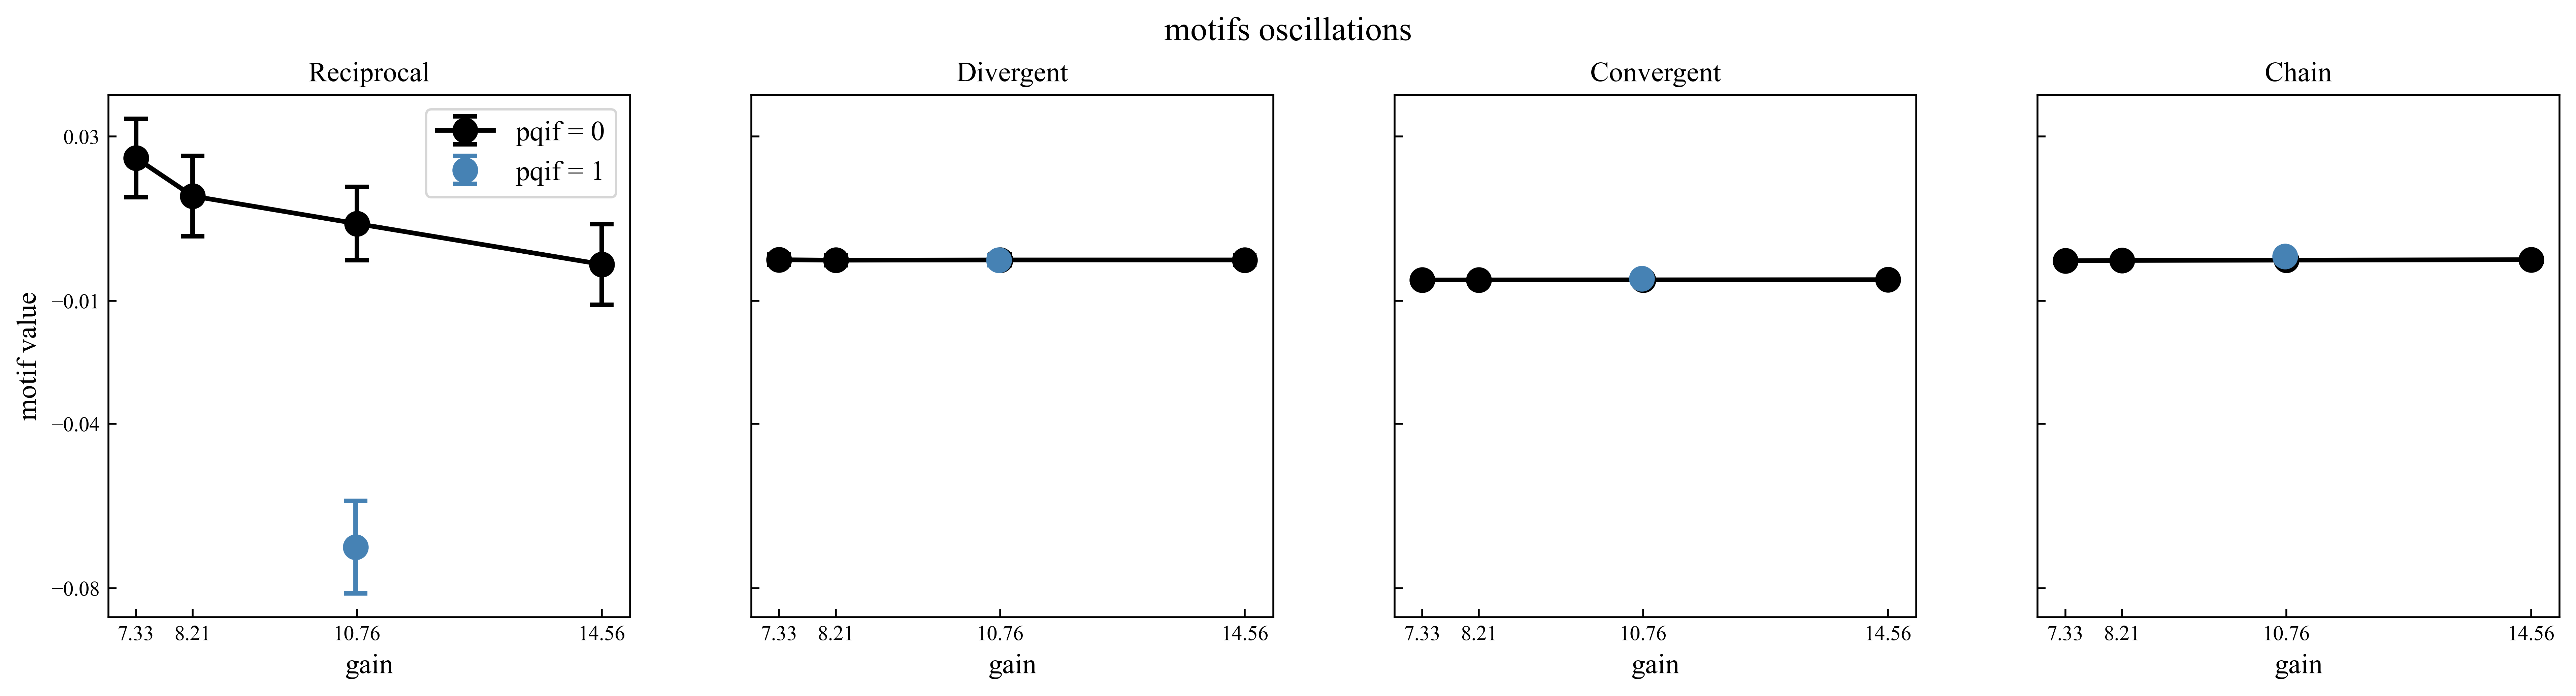

sequences


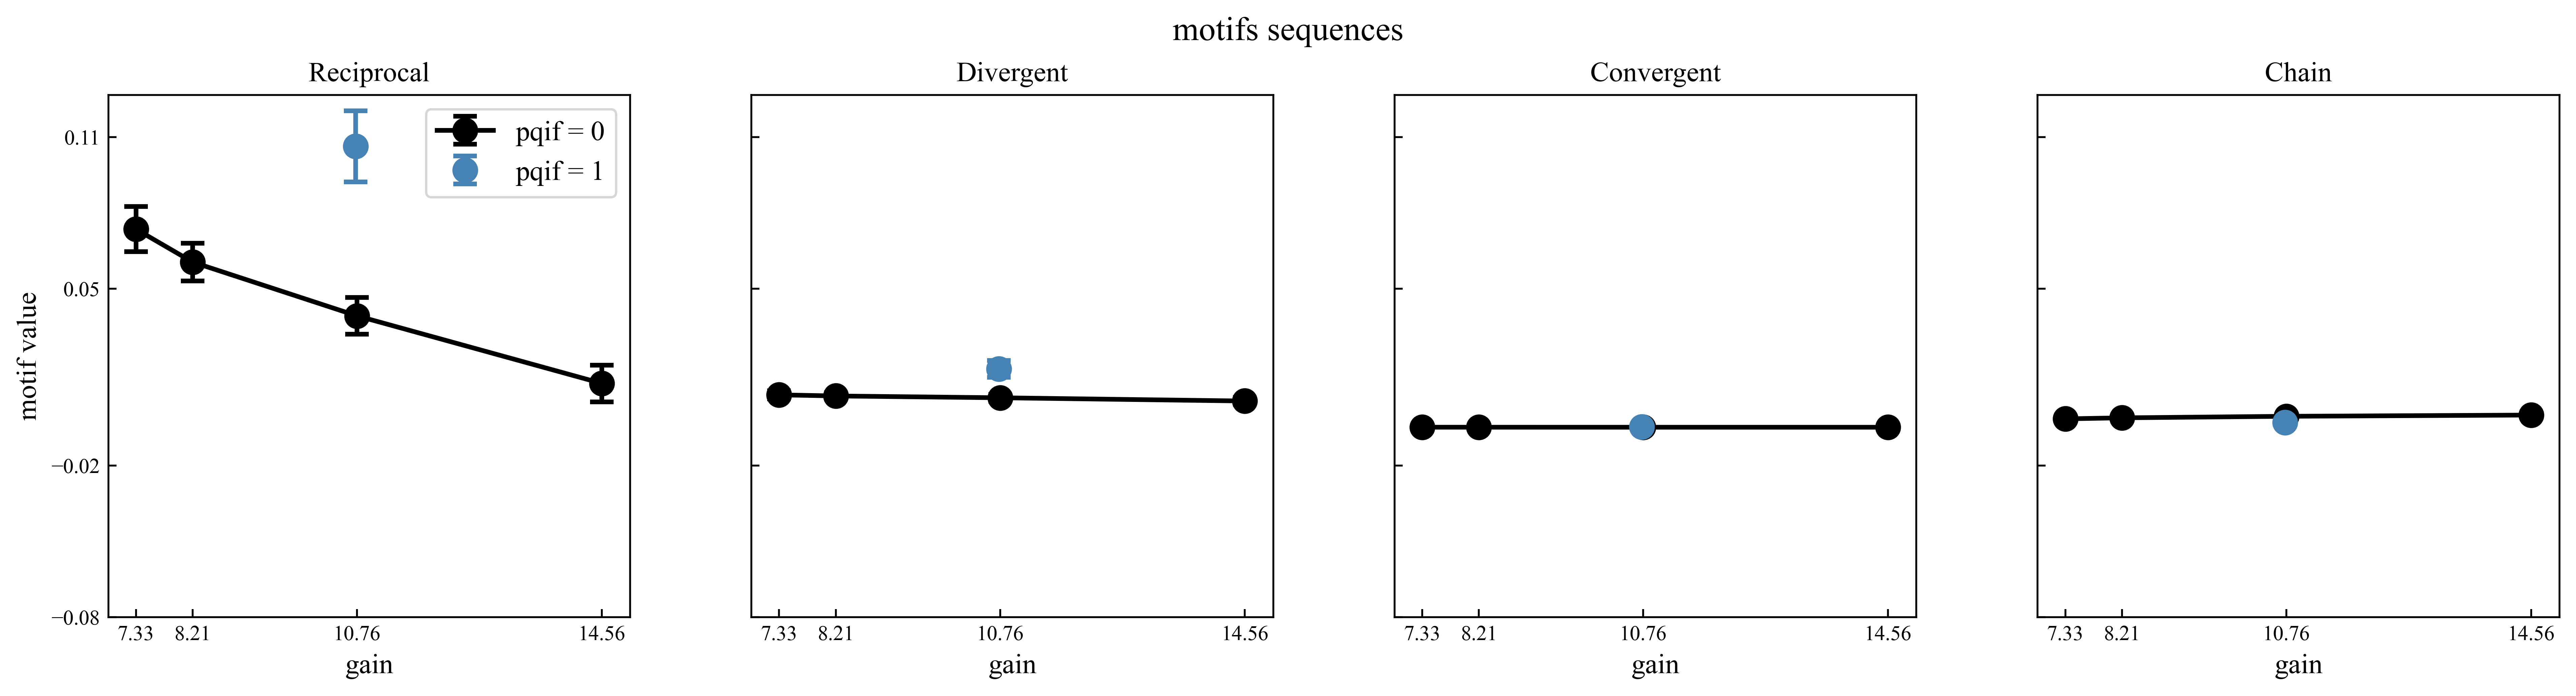

In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Parameters ----------------

base_path = Path(r"J:\ordinary_simulations")
figure_folder = Path("figures_all\july\motifs")
figure_folder.mkdir(parents=True, exist_ok=True)


pqif_values = [0, 0.25, 0.5, 0.75, 1]
names = ["LIF", "0.25", "0.5", "0.75", "QIF"]

vrest = [-8.5, -12.3, -17, -22]
slope = [14.44, 10.68, 8.65, 7.18]

motifs = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

motif_labels = {
    "tau_rec": "Reciprocal",
    "tau_div": "Divergent",
    "tau_con": "Convergent",
    "tau_chn": "Chain"
}


# ---------------- Plotting ----------------

pqif_homogeneous = [0, 1]

for cfg in configs:
    print(cfg.name)
    df_motif = pd.read_csv(f"motif_data_{cfg.name}.csv")

    fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

    lif_x = cfg.gains

    lif_means = {motif: [] for motif in motifs}
    lif_stds = {motif: [] for motif in motifs}

    # pqif = 0 across all gain values
    for gain in cfg.gains:
        df_filtered = df_motif[
            (df_motif["pqif"] == 0) &
            (df_motif["gain"] == gain) &
            (df_motif["nloop"] == 15)
        ]

        stats = df_filtered[motifs].agg(["mean", "std"])

        for motif in motifs:
            lif_means[motif].append(stats.loc["mean", motif])
            lif_stds[motif].append(stats.loc["std", motif])

    # pqif = 1: one point at its own gain value
    df_qif = df_motif[
        (df_motif["pqif"] == 1) &
        (df_motif["nloop"] == 15)
    ]

    qif_gain = df_qif["gain"].iloc[0]
    qif_stats = df_qif[motifs].agg(["mean", "std"])

    for j, motif in enumerate(motifs):
        ax = axs[j]

        # LIF / pqif = 0: black line across gains
        ax.errorbar(
            lif_x,
            lif_means[motif],
            yerr=lif_stds[motif],
            marker="o",
            linestyle="-",
            linewidth=2,       # connecting line thickness
            elinewidth=2,      # errorbar line thickness
            capsize=5,
            capthick=2,        # errorbar cap thickness
            markersize=10,
            color="black",
            # alpha=0.8,
            label="pqif = 0"
        )

        # QIF / pqif = 1: single blue point
        ax.errorbar(
            qif_gain,
            qif_stats.loc["mean", motif],
            yerr=qif_stats.loc["std", motif],
            marker="o",
            color="steelblue",
            linestyle="none",
            elinewidth=2,
            capsize=5,
            capthick=2,
            markersize=10,
            label="pqif = 1"
        )

        ax.set_title(motif_labels[motif])
        ax.set_xlabel("gain")
        ax.set_xticks(cfg.gains)
        ax.set_box_aspect(1)
        ax.set_xlim(6.9, 15)
        if cfg.name == "oscillations":
            ax.set_yticks(np.round(np.linspace(-0.08, 0.03, 4), decimals=2))
        else:
            ax.set_yticks(np.round(np.linspace(-0.08, 0.110, 4), decimals=2))
            
        # ax.set_ylim(-0.02, 0.20)

    axs[0].set_ylabel("motif value")
    axs[0].legend()

    fig.suptitle(f"motifs {cfg.name}")
    fig.tight_layout()
    fig_path = figure_folder / f"{cfg.name}_homogeneous_motif.svg"
    plt.savefig(fig_path, format="svg", bbox_inches="tight")
    plt.show()


In [48]:
print(np.round(np.linspace(-0.80, 0.110, 4), decimals=2))
print(np.round(np.linspace(-0.08, 0.03, 4), decimals=2))
# print(np.arange(-0.8, 0.11, ))

[-0.8  -0.5  -0.19  0.11]
[-0.08 -0.04 -0.01  0.03]
